# Bouquet — reconstruction example (g-file + p-file)

### What is this?

**Bouquet** propagates input uncertainty into Grad–Shafranov equilibria: it
perturbs the measured inputs within their error bars and re-solves each draw
with **TokaMaker** (OpenFUSION Toolkit), producing a *bouquet* of equilibria
spanning what the data allows.

This notebook starts from an **EFIT g-file** plus an **Osborne p-file**,
reconstructs a self-consistent baseline (separated inductive + bootstrap
current, matched l_i), and generates a bouquet. Everything is synthetic,
non-proprietary DIII-D-like data, so it runs end to end.

**Layout:** (1) look at the inputs, (2) a minimal run, (3) plot the outputs,
(4) upgrade to ψ-dependent uncertainties, (5) the full switchboard, (6) a
comprehensive run + the same plots. The companion
`bouquet_D3Dlike_omas_example.ipynb` does all this from a FUSE IMAS dataset.

> **Prereq:** the OpenFUSION Toolkit on `PYTHONPATH`
> (`export PYTHONPATH=/path/to/OpenFUSIONToolkit/build_release/python:$PYTHONPATH`).


In [1]:
import os
try:
    import OpenFUSIONToolkit  # noqa: F401 -- bouquet imports it lazily, so check up front
except ModuleNotFoundError as e:
    raise SystemExit(
        "OpenFUSIONToolkit not importable. Put OFT on PYTHONPATH, e.g.\n"
        "  export PYTHONPATH=/path/to/OpenFUSIONToolkit/build_release/python:$PYTHONPATH"
    ) from e
import bouquet as bq
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
EC = 1.602176634e-19   # elementary charge (p = n·k·T in SI)
GFILE = 'D3Dlike_Hmode_baseline.geqdsk'   # EFIT equilibrium  (shape + current)
PFILE = 'D3Dlike_Hmode_baseline.peqdsk'   # Osborne kinetic profiles (n, T)
MESH  = 'DIIID_mesh.h5'                    # TokaMaker finite-element mesh
print('bouquet', bq.__version__, 'ready')


bouquet 1.3.1 ready


## 1. Look at the inputs

Before solving anything, here's what we're feeding in, shown with the same
plotters used for the bouquet outputs below. The **g-file** gives the
equilibrium (LCFS shape + pressure / q / current / P' / FF'); the **p-file**
gives the kinetic profiles (electron/ion density and temperature vs. ψ_N).

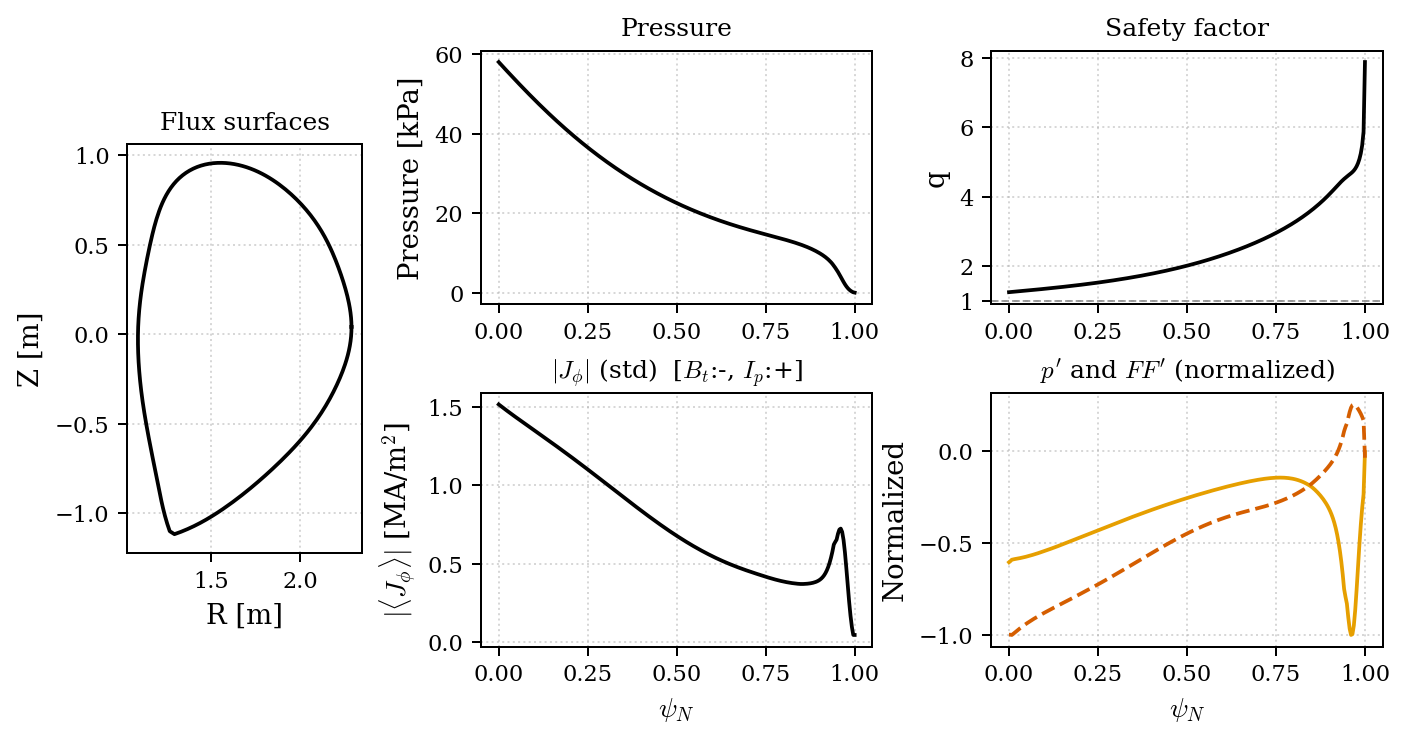

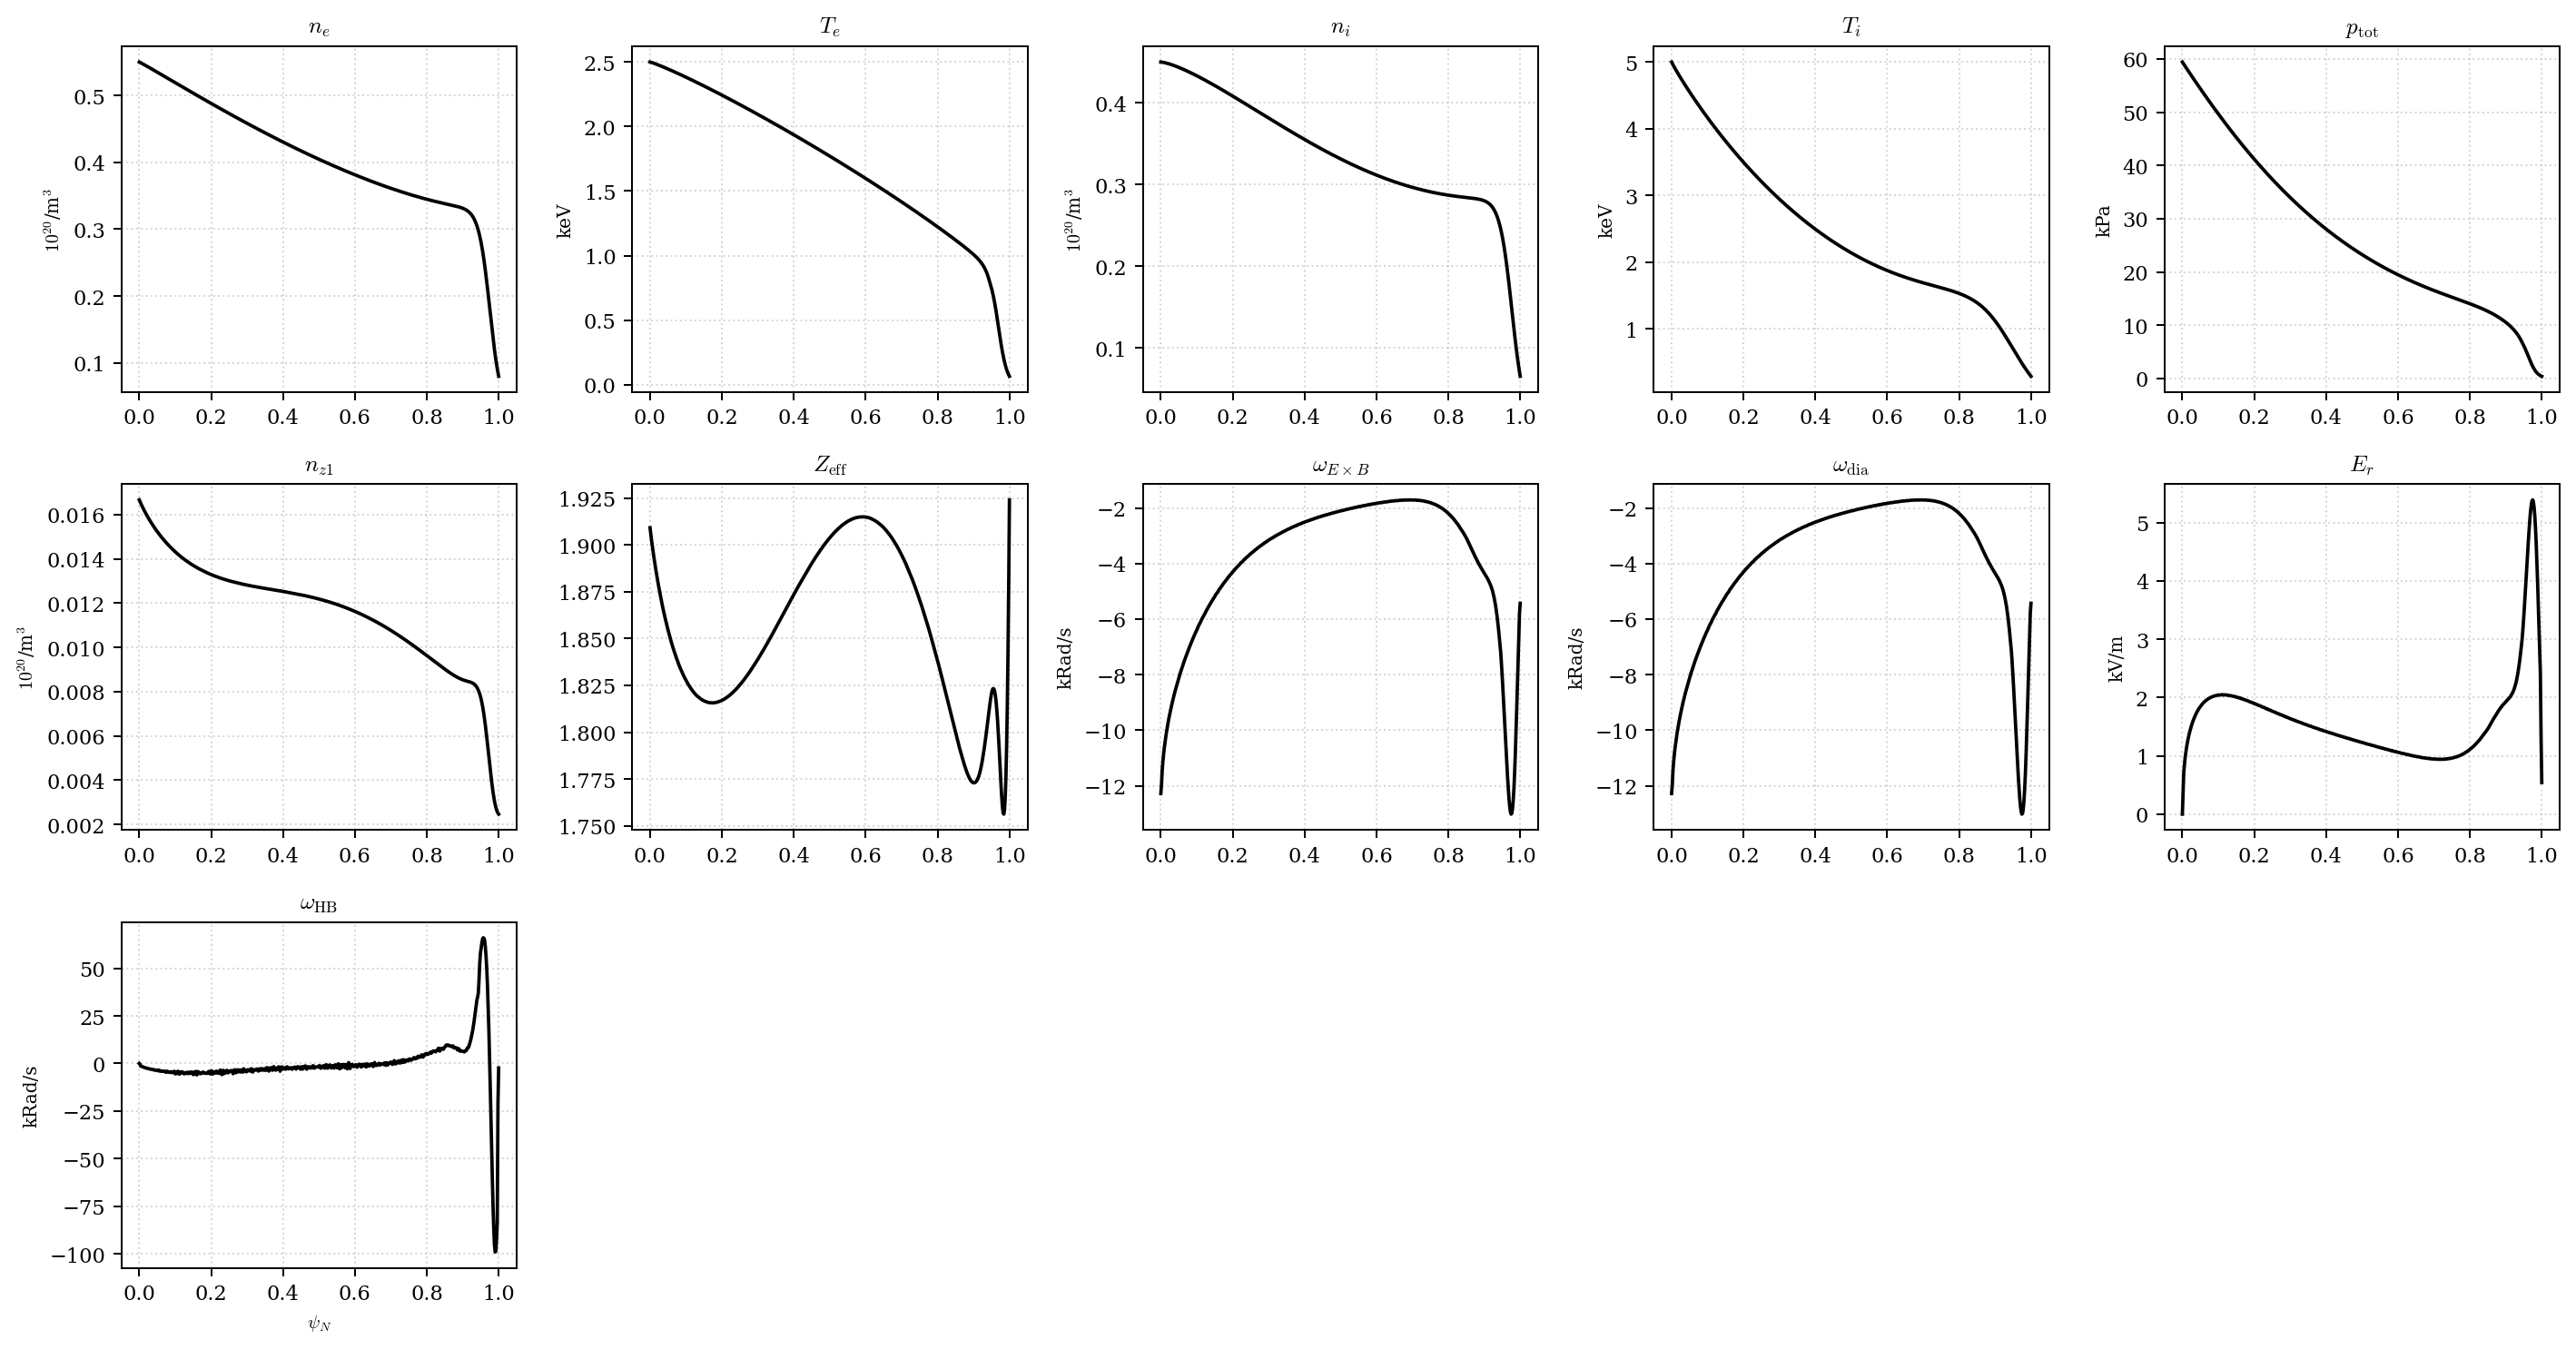

In [2]:
# plot_geqdsk_bouquet / plot_pfile_bouquet flags: x_coord={psi_N|rho}  scan_key  count=<draw idx>  h5path=<archive>
# the input equilibrium (g-file): LCFS + pressure, q, |j_phi|, P', FF'
bq.plot_geqdsk_bouquet(GFILE); plt.show()
# the input kinetic profiles (p-file): n_e, n_i, T_e, T_i
bq.plot_pfile_bouquet(PFILE); plt.show()

## 2. A minimal run

Four pieces: create the driver, set the **uncertainty envelope** (how far each
draw may wander), set the **GPR correlation lengths** (how *smooth* in ψ each
perturbation is), then reconstruct + generate.

The kinetic σ are per-channel fractions — ne/Te at 5 %, Ti at 10 %, `j_phi` at
5 %. The GPR lengths control the radial correlation of each perturbation
(smaller = wigglier).

**Densities follow a Z_eff-consistent scheme by default.** Each draw perturbs
n_e, T_e, T_i and **Z_eff** (the `zeff_scalar_sigma`, default ±5 %), and the
main-ion density n_i is *derived* from (n_e, Z_eff) by single-impurity
quasineutrality — so n_i, n_z and Z_eff stay mutually consistent and
`ni_scalar_sigma` is unused. The impurity is set by `impurity_Z` (carbon Z=6
here; **set it for your machine**). Pass `zeff_scalar_sigma=0` to instead draw
n_i independently and hold Z_eff at baseline.


In [3]:
# from_geqdsk flags: n_draws  header  impurity_Z=6.0  cocos=1  time
HEADER = 'D3Dlike_Hmode'          # output -> f'{HEADER}.h5'
run = bq.Bouquet.from_geqdsk(GFILE, profiles=PFILE, mesh=MESH, n_draws=15, header=HEADER,
                             impurity_Z=6.0)   # carbon; set per machine (W~74, Be 4, Ne 10)

# uncertainty envelope (per-channel fractional σ)
run.uncertainty.ne_scalar_sigma = 0.05;  run.uncertainty.te_scalar_sigma = 0.05
run.uncertainty.ti_scalar_sigma = 0.10
run.uncertainty.jphi_scalar_sigma = 0.05
run.uncertainty.zeff_scalar_sigma = 0.05   # ENABLES the Z_eff channel -> n_i derived per draw
                                           # (set 0.0 for independent n_i; ni_scalar_sigma then used)
# GPR correlation lengths (ψ_N units): density / temperature / current
run.uncertainty.n_ls, run.uncertainty.t_ls, run.uncertainty.j_ls = 0.5, 0.4, 0.25
run.generation.seed = 42          # reproducible GPR draws
run.generation.scan_key = 2100    # label this bouquet by time [ms] (scan/2100/ in the .h5)


`reconstruct()` separates the g-file's total current into inductive + bootstrap
and matches the EFIT `l_i`, printing a **fidelity report** (TokaMaker vs. the
input g-file). Then `generate/filter/export` builds and screens the ensemble.

In [4]:
run.reconstruct();    # reconstruct the baseline + print the fidelity summary

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  fix/bootstrap-pchip-derivatives
Revision id:         19e08b2

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    1

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    3
  Minlev =   -1


 Inverting real matrix
   Time =    2.2039999999999998E-003




=== Reconstruction — D3Dlike_Hmode_baseline.geqdsk =========== PASS ✅
  converged    yes
  Ip           1.200 MA      (input 1.200 MA, -0.00%)
  l_i(3)       0.654         (input 0.654, +0.01%)
    l_i(1)x    0.872         (input 0.841, +3.65%)
  q0           1.25          (input 1.24, +0.63%)
  q95          4.58          (input 4.59, -0.14%)
  beta_N       1.34          (input 1.34, -0.20%)
  beta_p       0.66          (input 0.64, +3.46%)
  kappa        1.761         (input 1.739, +1.29%)
  delta        0.459         (input 0.442, +4.02%)
  j_sep(.99)   0.254 MA/m²   (input 0.167 MA/m², +51.60%)
  W_MHD        0.590 MJ      (input 0.589 MJ, +0.16%)
  boundary     RMS 2.49 mm   max 7.40 mm   axis off 0.17 mm
  jphi resid   core RMS 0.005   edge RMS 0.062 MA/m²
  l_i post-7   0.65607       (target 0.65384 = step-6 matched, +0.342%, band ±5.00%)


In [5]:
# sigma=0 regression guard: the per-draw SWB spike must reproduce the
# baseline j_BS split with unperturbed kinetics (costs ~1 SWB call, ~1 min).
# Catches recon/draw-path inconsistencies (axis smoothing, classification,
# regridding) before any draw compute is spent.
chk = run.verify_sigma0_consistency()
assert chk['passed'], chk


 >>> Matching input core j_phi with G-S solution



 >>> Finding optimal j_phi scale factor

--- Checking scale_j0 = 1.0000 ---


   Input j_0:  1.2486e+06
   Output j_0: 1.2951e+06
   Mismatch:  3.594%

--- Checking scale_j0 = 1.2000 ---


   Input j_0:  1.4936e+06
   Output j_0: 1.3521e+06
   Mismatch:  10.465%
--- Optimization Iteration 1 ---

--- Checking scale_j0 = 1.0495 ---


   Input j_0:  1.3092e+06
   Output j_0: 1.3107e+06
   Mismatch:  0.110%
Converged! Optimal scale factor: 1.0495

 >>> Iterating on H-mode equilibrium solution


[sigma0-check] PASS: max|spike0 - j_BS| = 0.0015 MA/m² (0.28% of peak, worst at psi_N=0.961; tol 2.0%)


### Reconstruction fidelity — input vs reconstruction

Before spending compute on the bouquet, confirm TokaMaker reproduced the input.
`plot_input_vs_recon(run)` overlays the **raw input g-file** (dotted) against
the **reconstructed baseline** (solid) for pressure, j_phi, q, and the
separatrix — the last colour-coded by boundary deviation (green→red). Call it
right after `reconstruct()` (before `generate()`, which re-points the solver to
the draws).

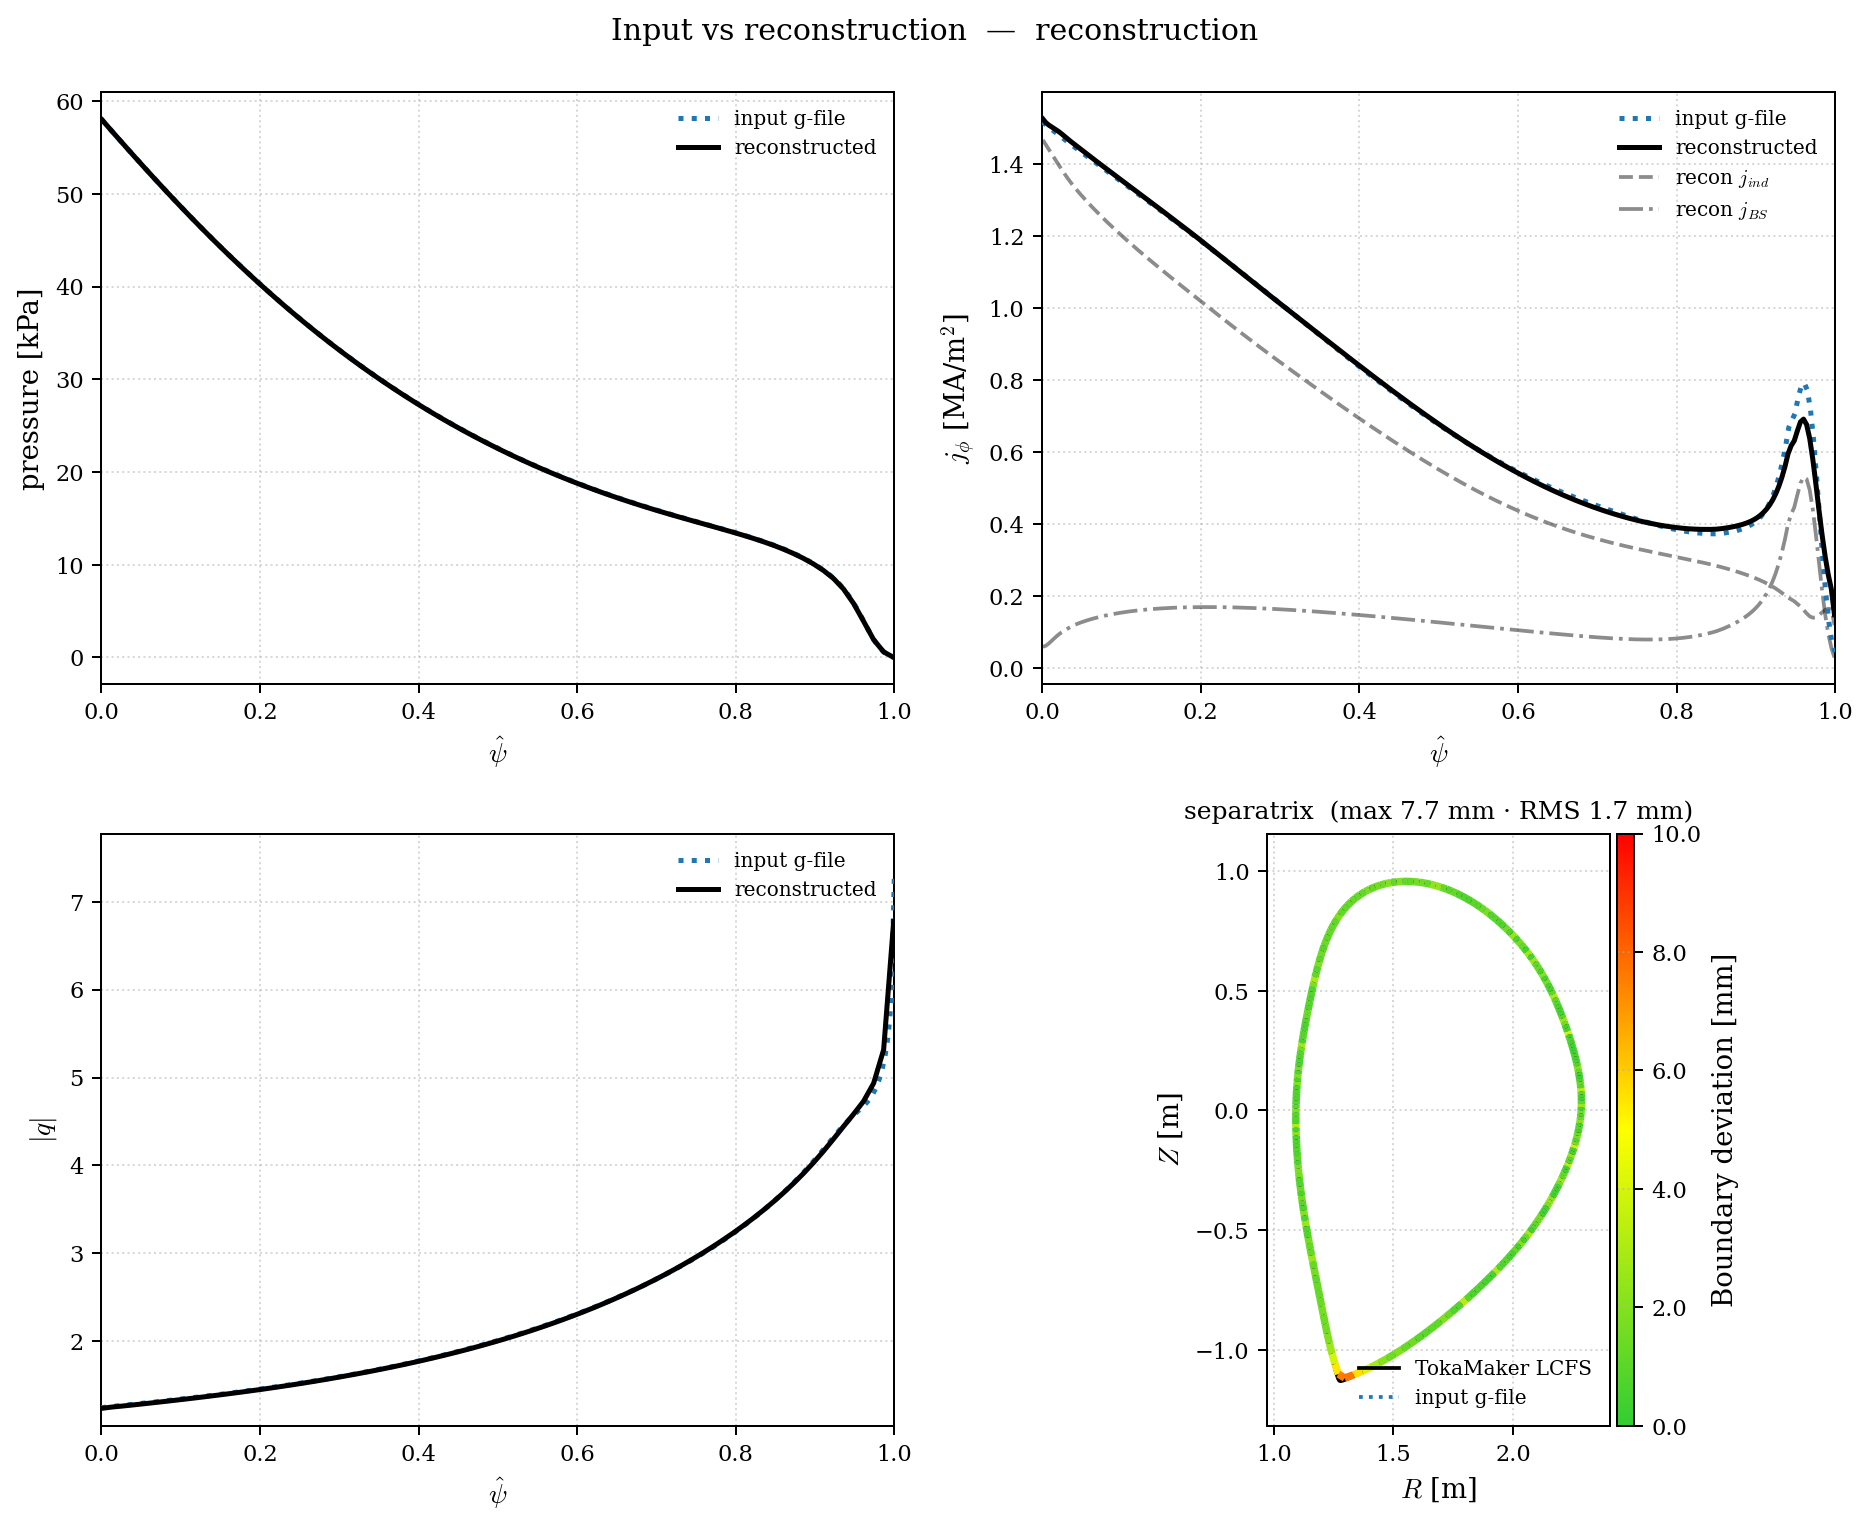

In [6]:
# plot_input_vs_recon flags: npsi=<q/pressure grid pts>  max_dev_mm=<separatrix colour scale>
bq.plot_input_vs_recon(run); plt.show()

In [7]:
run.generate(); run.filter(); run.export()    # perturb + solve + screen the draws

  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.75e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 125)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 4.5e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 500)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 7.659e+04)



=== Bouquet — D3Dlike_Hmode =====================  9/15 in-spec (60%)
  draws         15 generated
  coil spec     9/15 within ±2%   (6 out-of-spec)
  boundary      RMS median 2.16 mm   max 3.82 mm


'D3Dlike_Hmode_selected.h5'

## 3. Plot the bouquet outputs

Five views of the ensemble:
- **`plot_traces`** — per-draw l_i (with the acceptance band), LCFS deviation,
  and the anchor-displacement heatmap,
- **`plot_bouquet`** — kinetic / pressure / j_phi / boundary profile families,
- **`plot_coil_currents`** — coil-drift heatmap (a saturated cell is at/over
  spec; the VSC pair sits below the rule),
- **`plot_geqdsk_bouquet`** — the perturbed flux-surface shapes (g-file path only),
- **`plot_pfile_bouquet`** — perturbed kinetic profiles on the p-file grid.

Filled markers are selected draws; open markers were excluded by the filter
(section below).


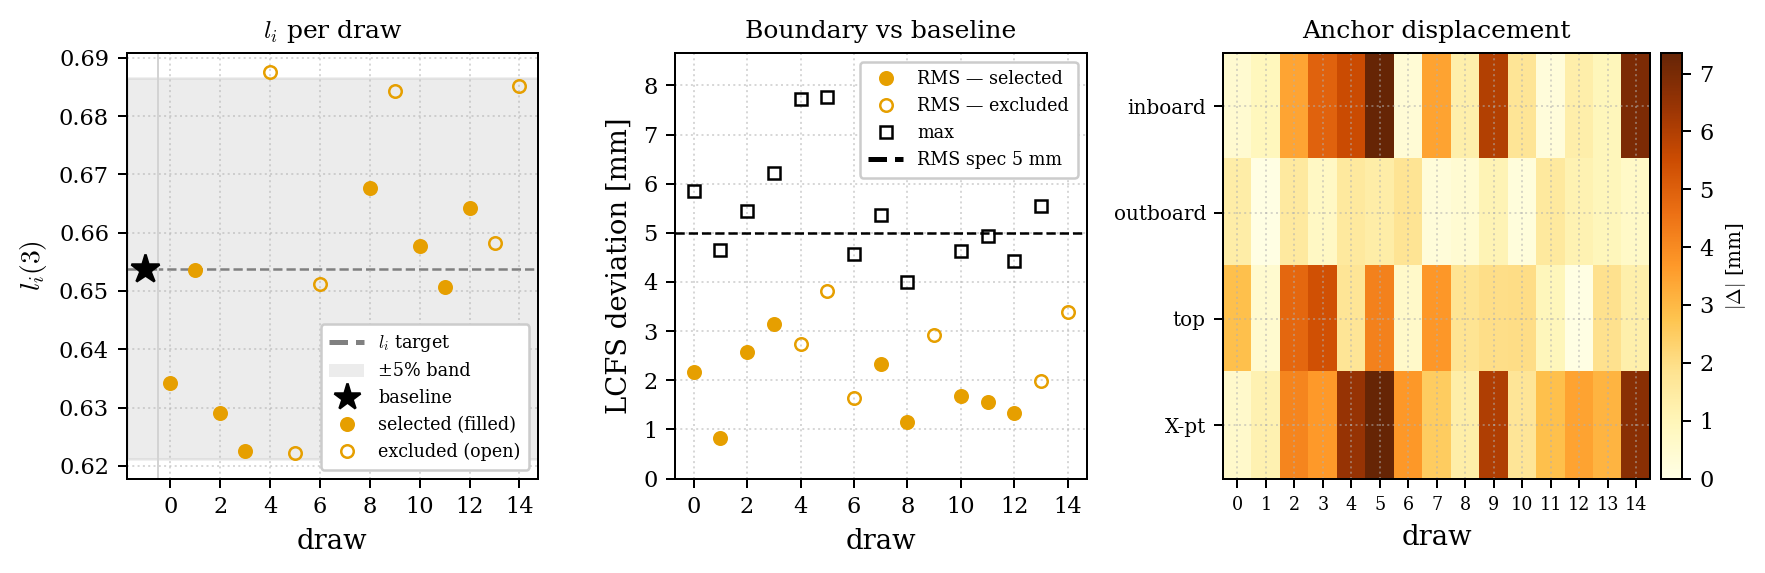

In [8]:
# plot_traces flags: scan_key={int|'all'}  li_band=<l_i accept band>  rms_max_mm=<LCFS RMS cut>
bq.plot_traces(HEADER + '.h5', scan_key=2100, li_band=run.generation.l_i_tolerance,
            rms_max_mm=run.filtering.rms_max_mm); plt.show()


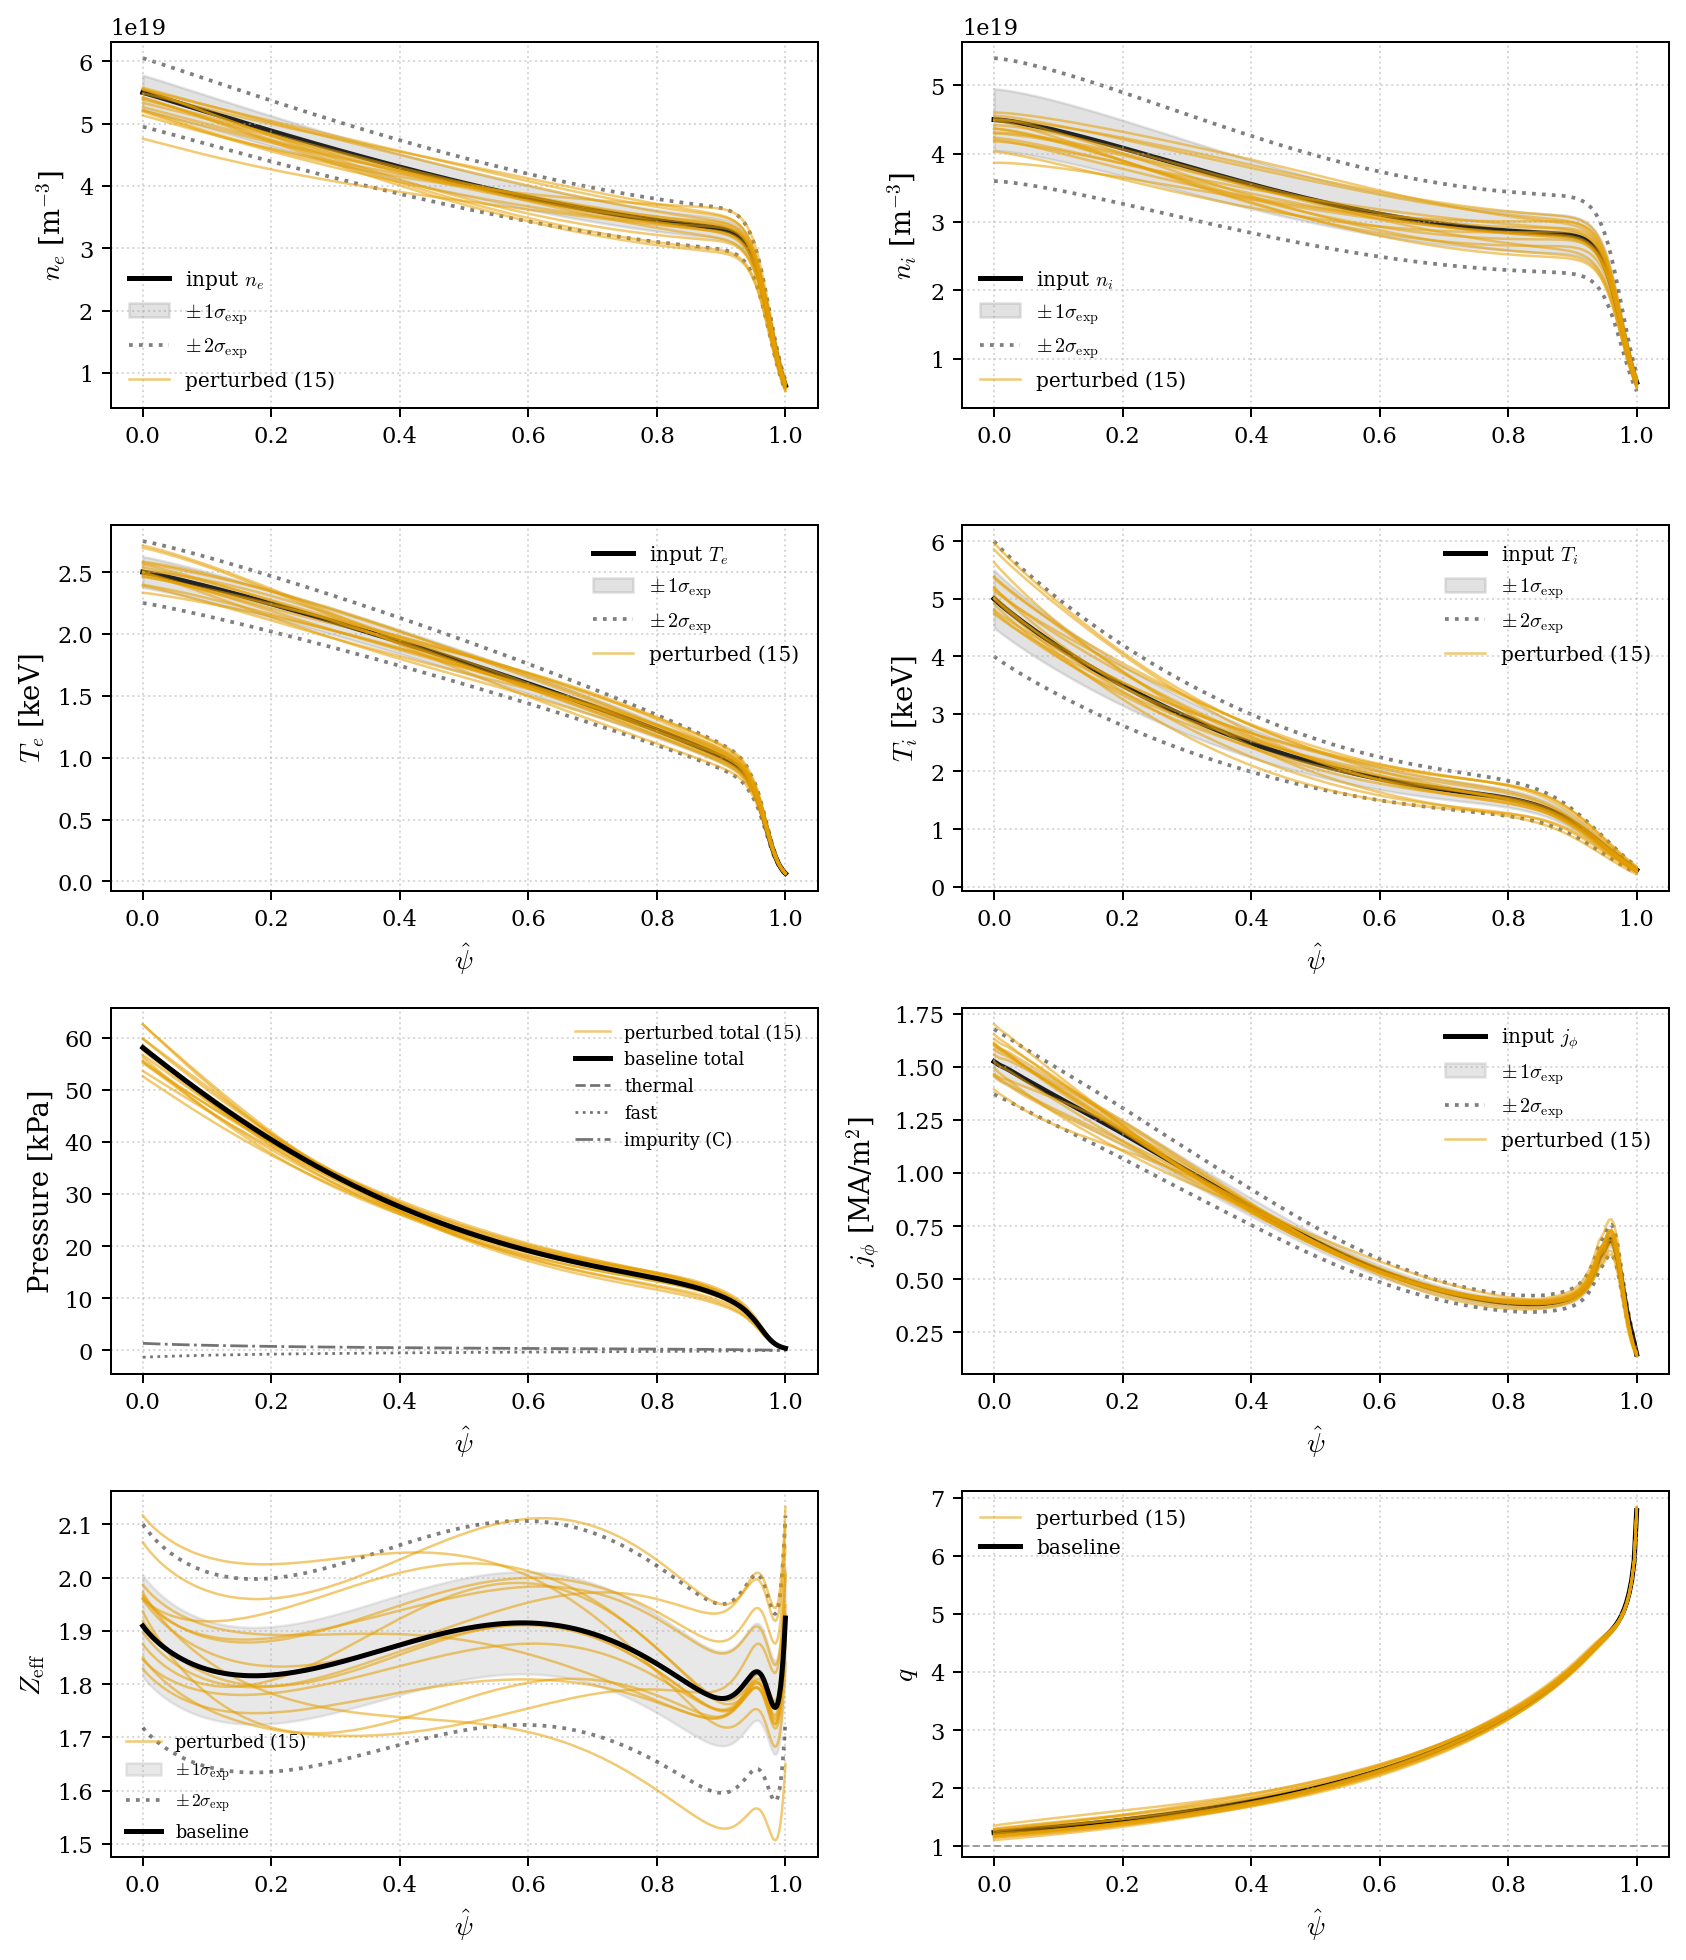

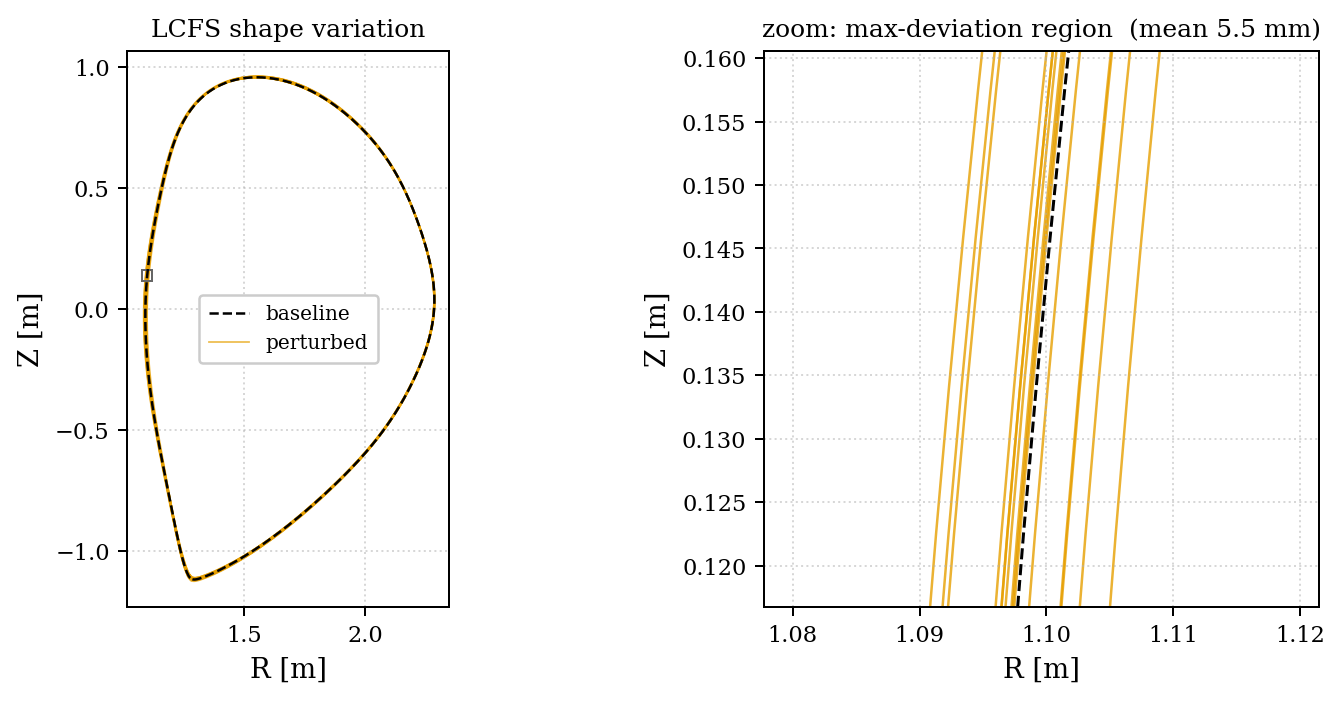

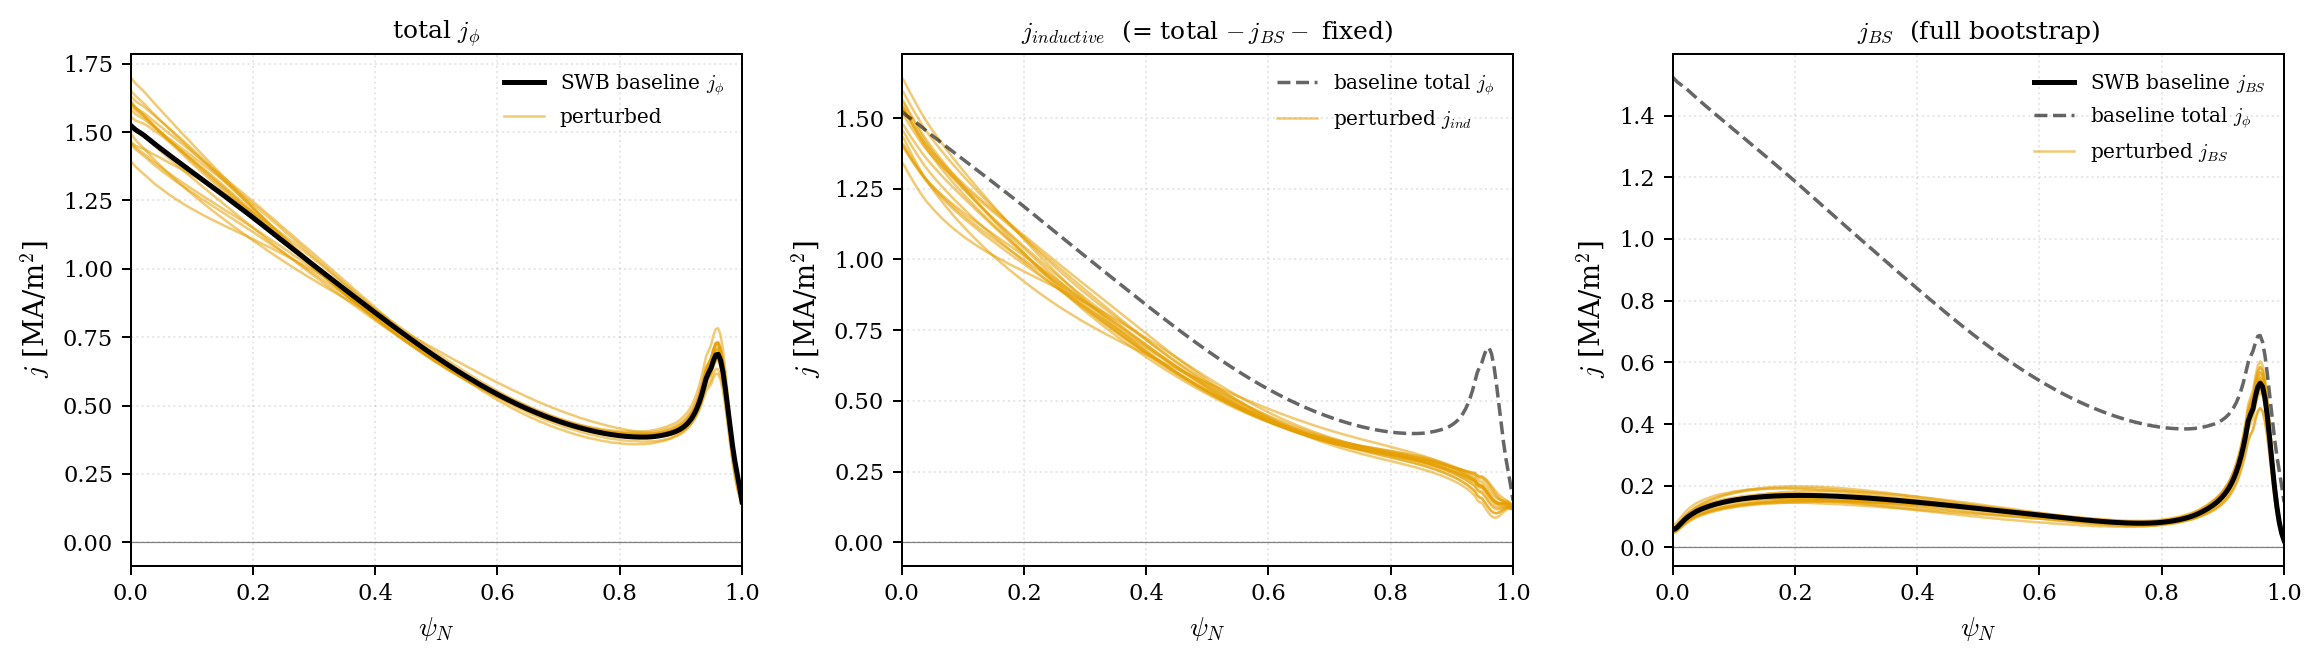

In [9]:
# plot_bouquet flags: mode={kinetic|pressure|j-phi|boundary|all}  selection={all|selected|excluded}  layout={stack|row}  pub_style={F|T}
bq.plot_bouquet(HEADER + '.h5', scan_key=2100, mode='all');

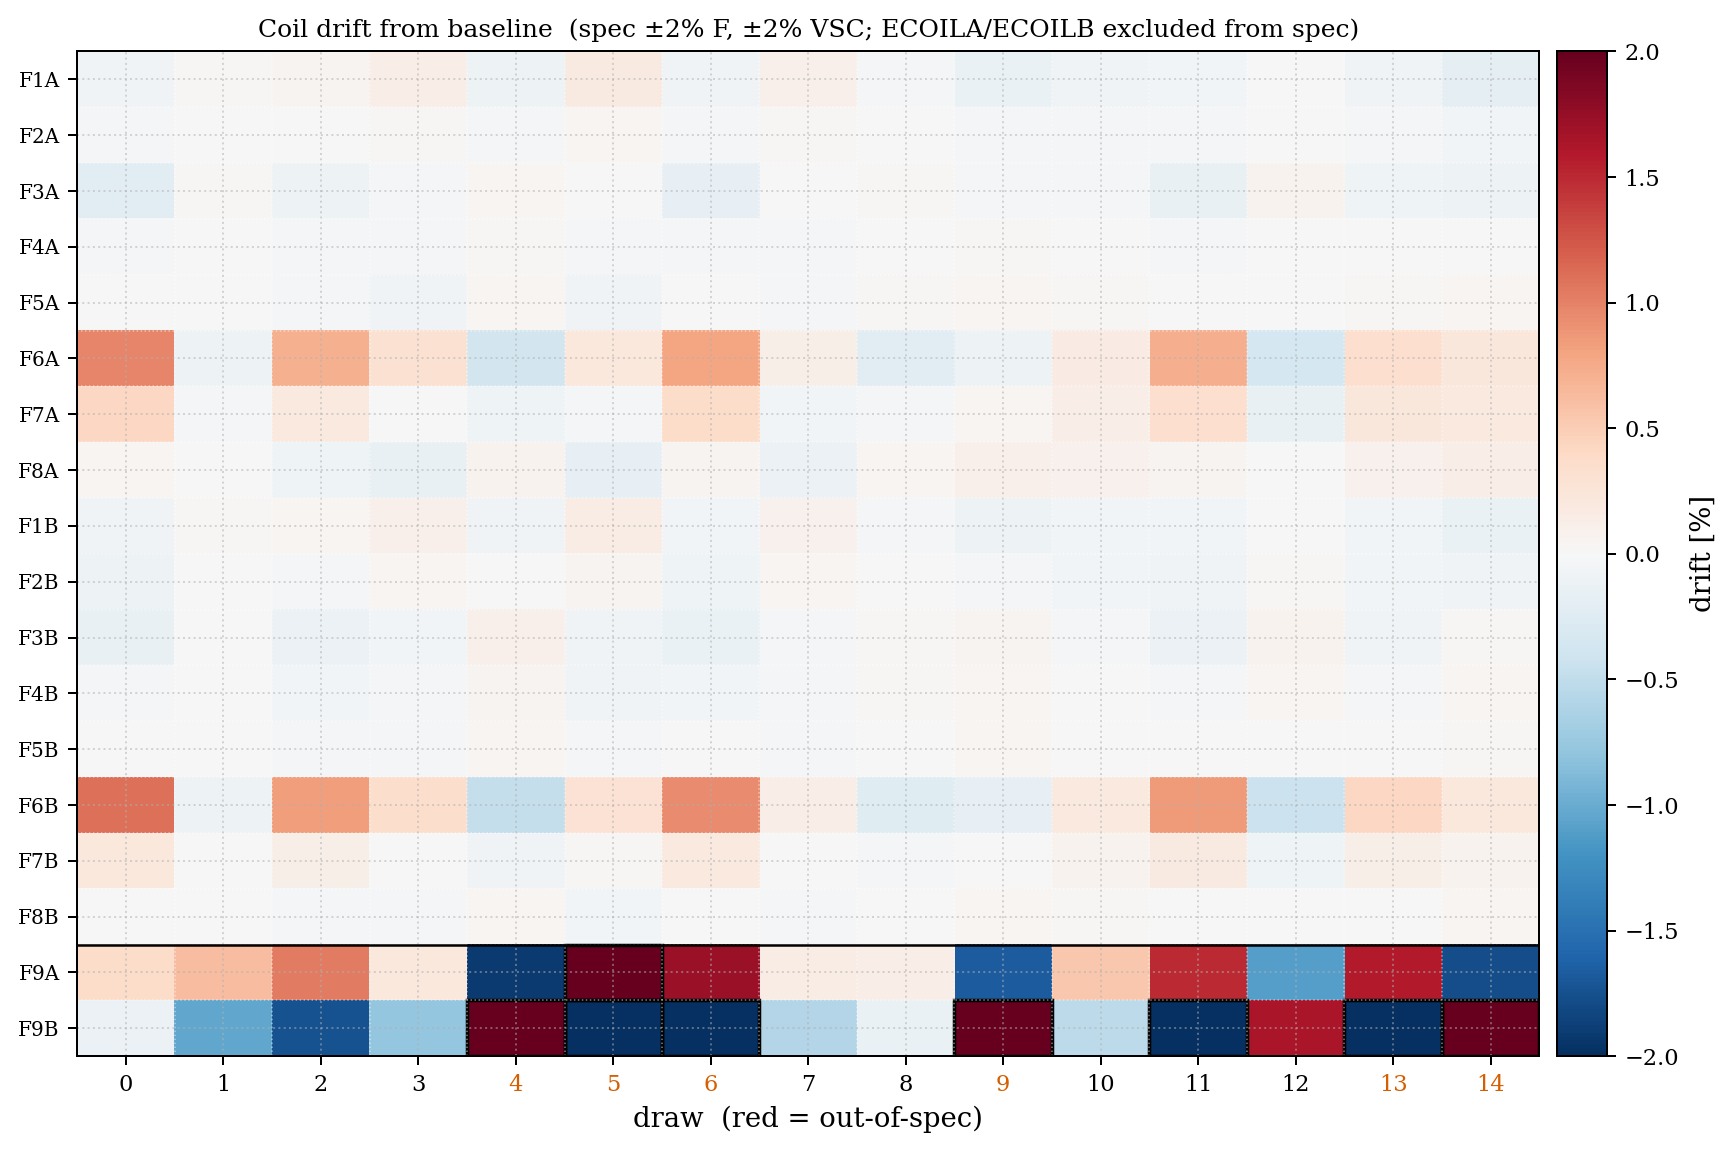

In [10]:
# plot_coil_currents flags: vsc_coils=('F9A','F9B')  exclude_coils=('ECOILA','ECOILB')  annotate={None(auto)|T|F}
# per-coil drift heatmap: saturated = at/over spec, black edge = violation,
# red draw label = out-of-spec draw, VSC pair below the rule
bq.plot_coil_currents(HEADER + '.h5', scan_key=2100); plt.show()


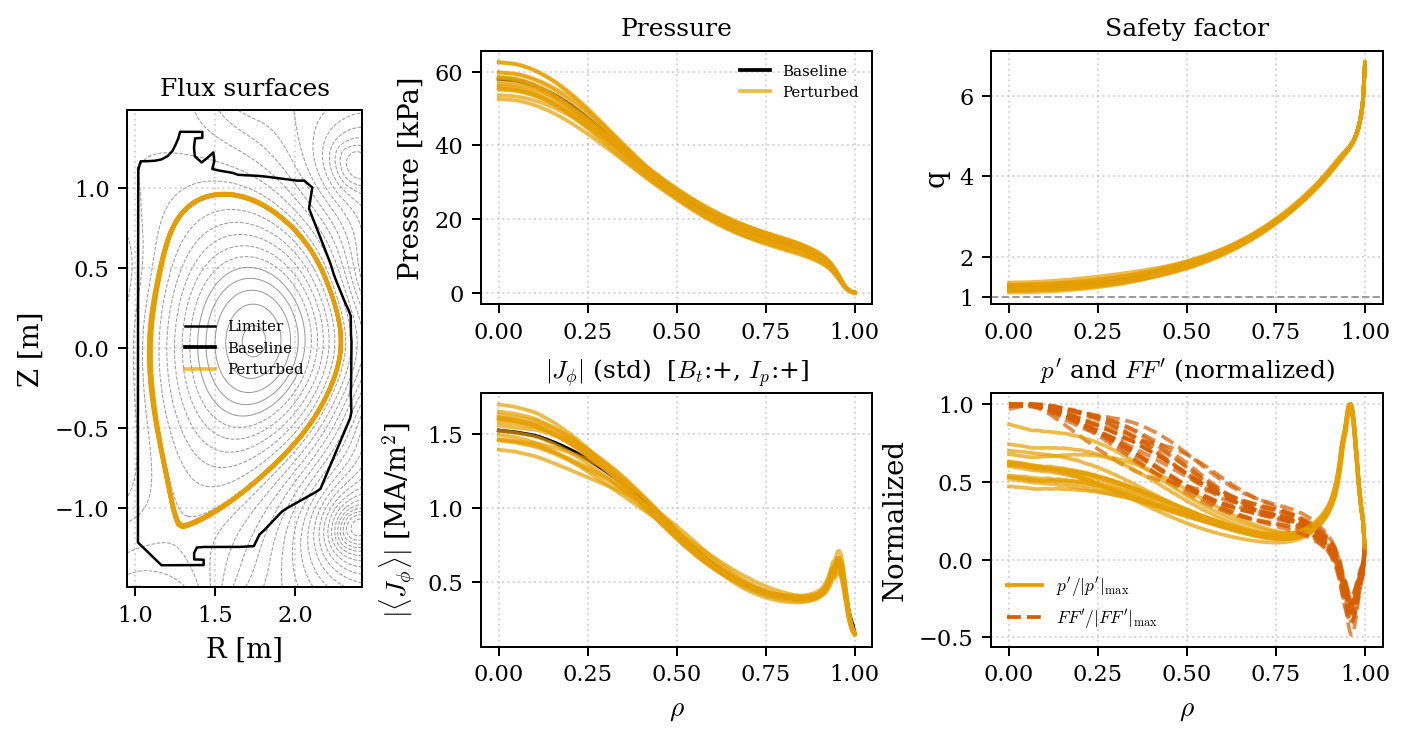

In [11]:
bq.plot_geqdsk_bouquet(h5path=HEADER + '.h5', scan_key=2100, x_coord='rho'); plt.show()

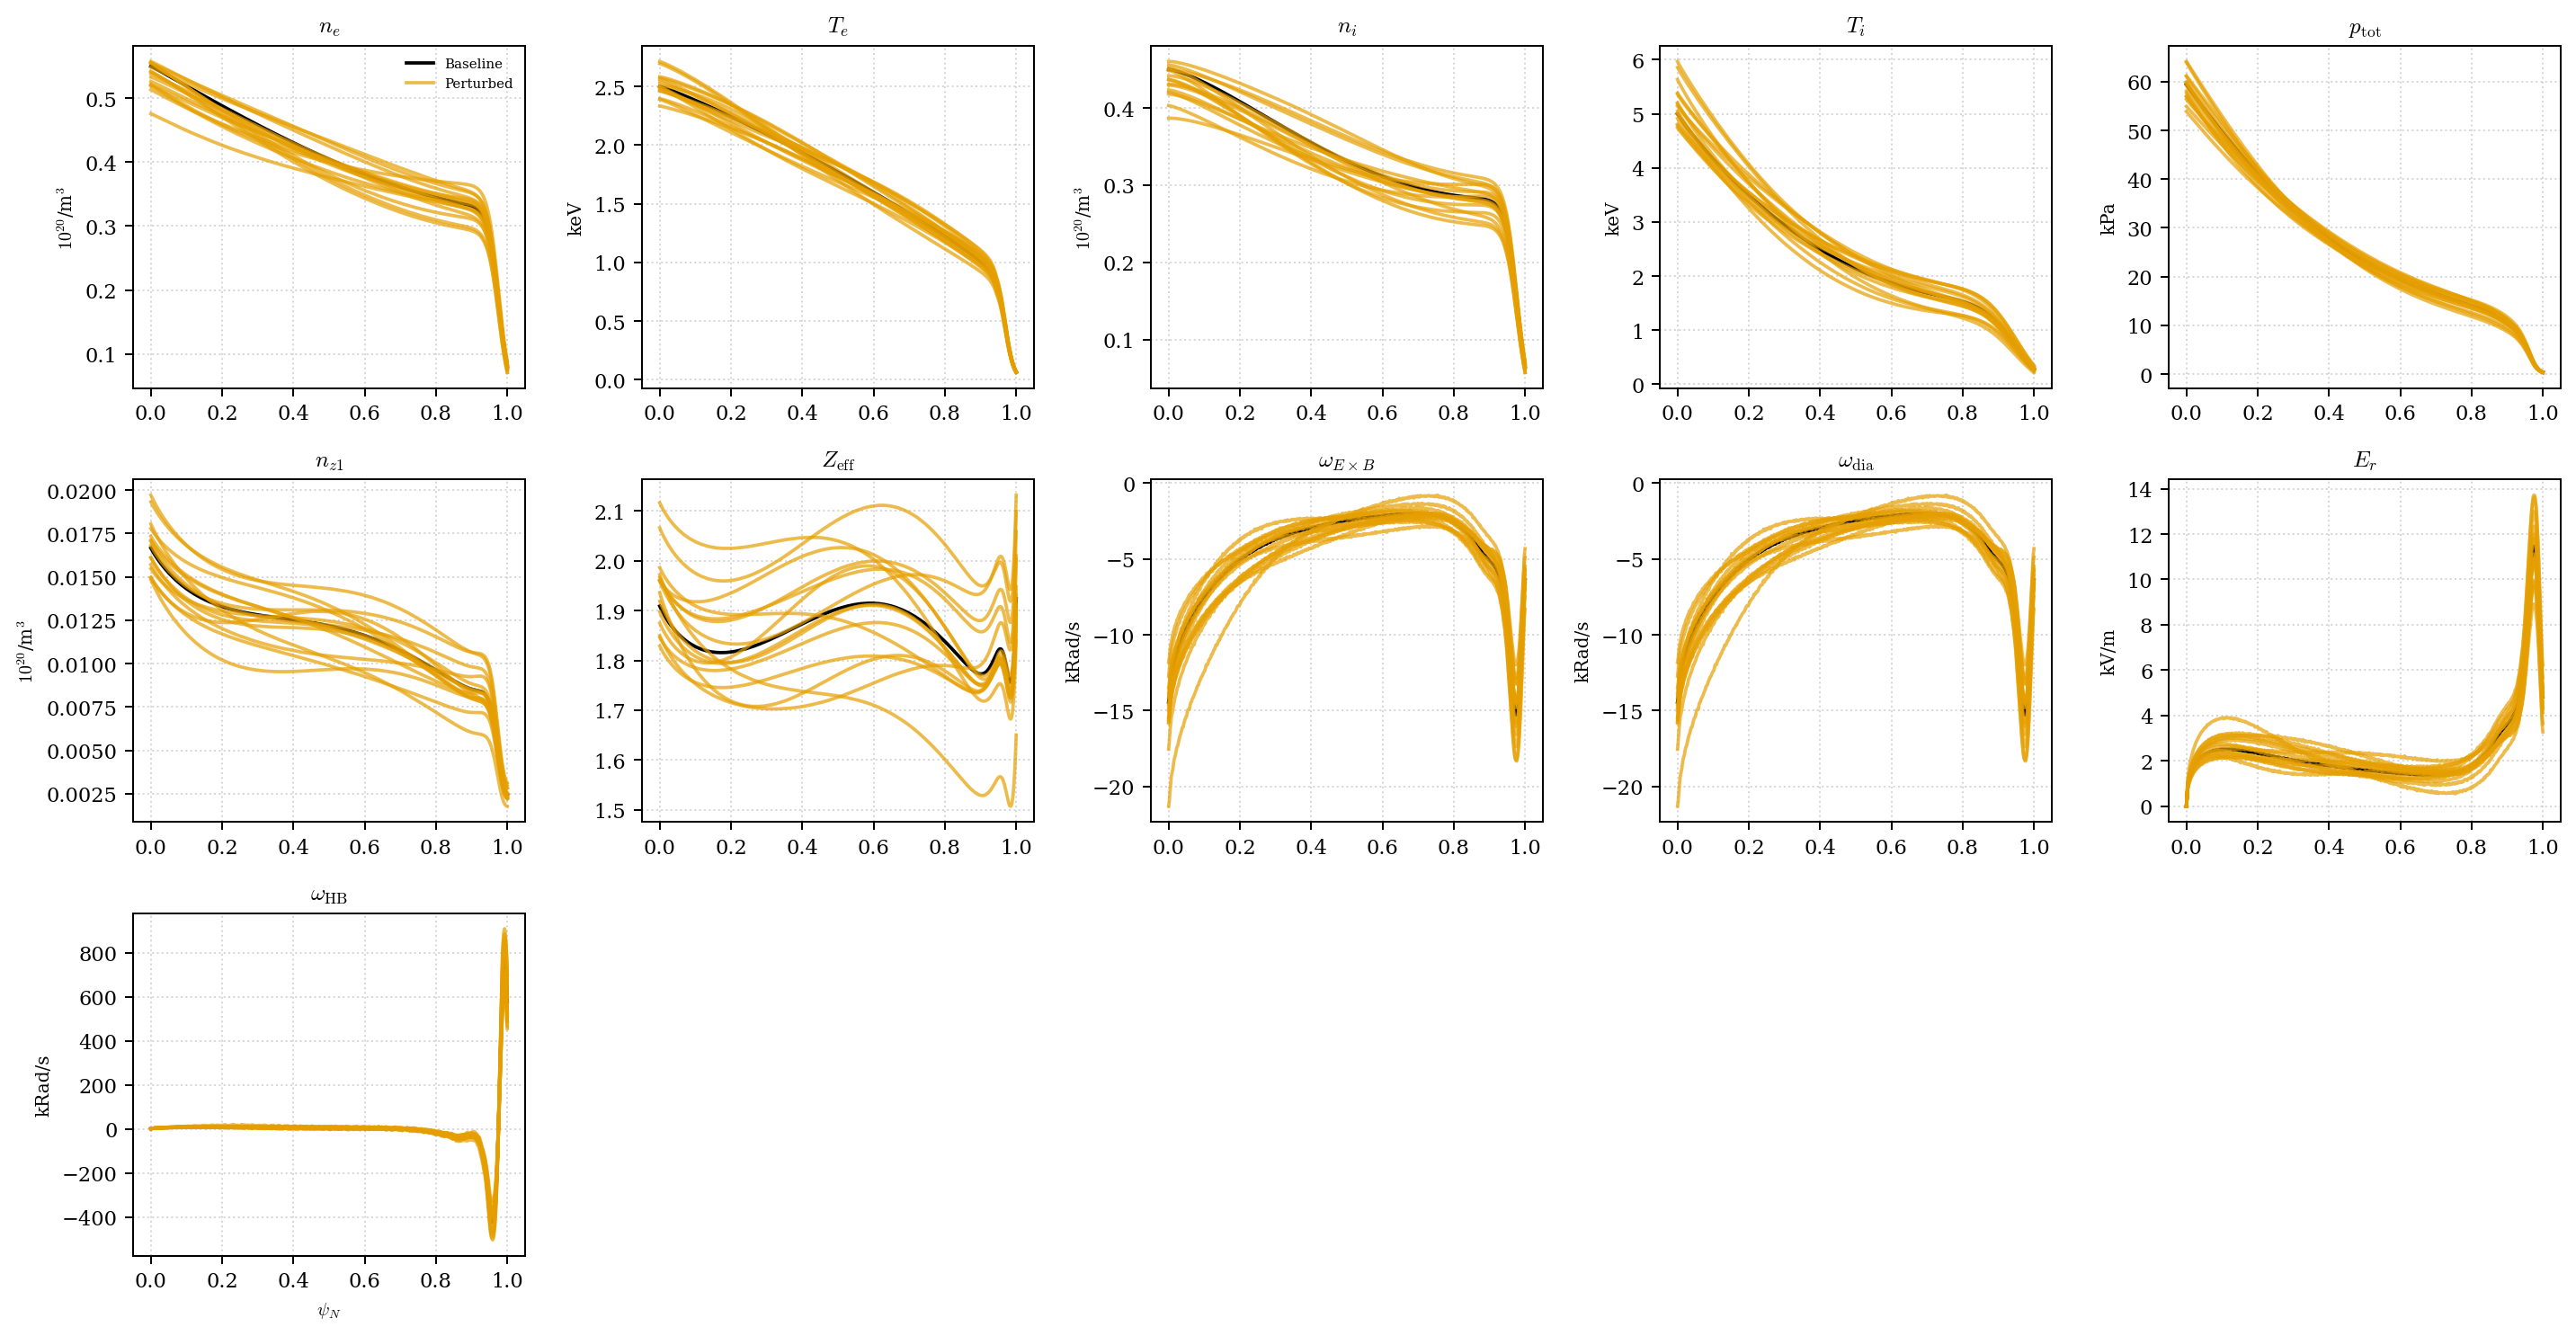

In [12]:
bq.plot_pfile_bouquet(h5path=HEADER + '.h5', scan_key=2100, x_coord='psi_N'); plt.show()

### The in-spec filter

`run.filter()` already screened the draws; here is what it did. **Coil-current
filter** — the binding constraint: a draw passes only if every non-VSC F-coil
stays within ±2 % of baseline (and the VSC pair within its own limit).
**Boundary filter** — rejects draws whose LCFS strays too far (RMS, mm).
`selected` is the AND of both; `export()` wrote the selected-only file.

`plot_spec_summary` shows the whole story at once: each draw's **fraction of
spec** for both criteria (1.0 = exactly at spec), and the **spec box** — where
every draw lands relative to both limits simultaneously.


coil-current in-spec: 9/15 (6 out-of-spec)
boundary RMS [mm]: median 2.16  95th 3.52  max 3.82
selected (deliverable): 9 draws [0, 1, 2, 3, 7, 8, 10, 11, 12]
excluded (out-of-spec): 6 draws [4, 5, 6, 9, 13, 14]


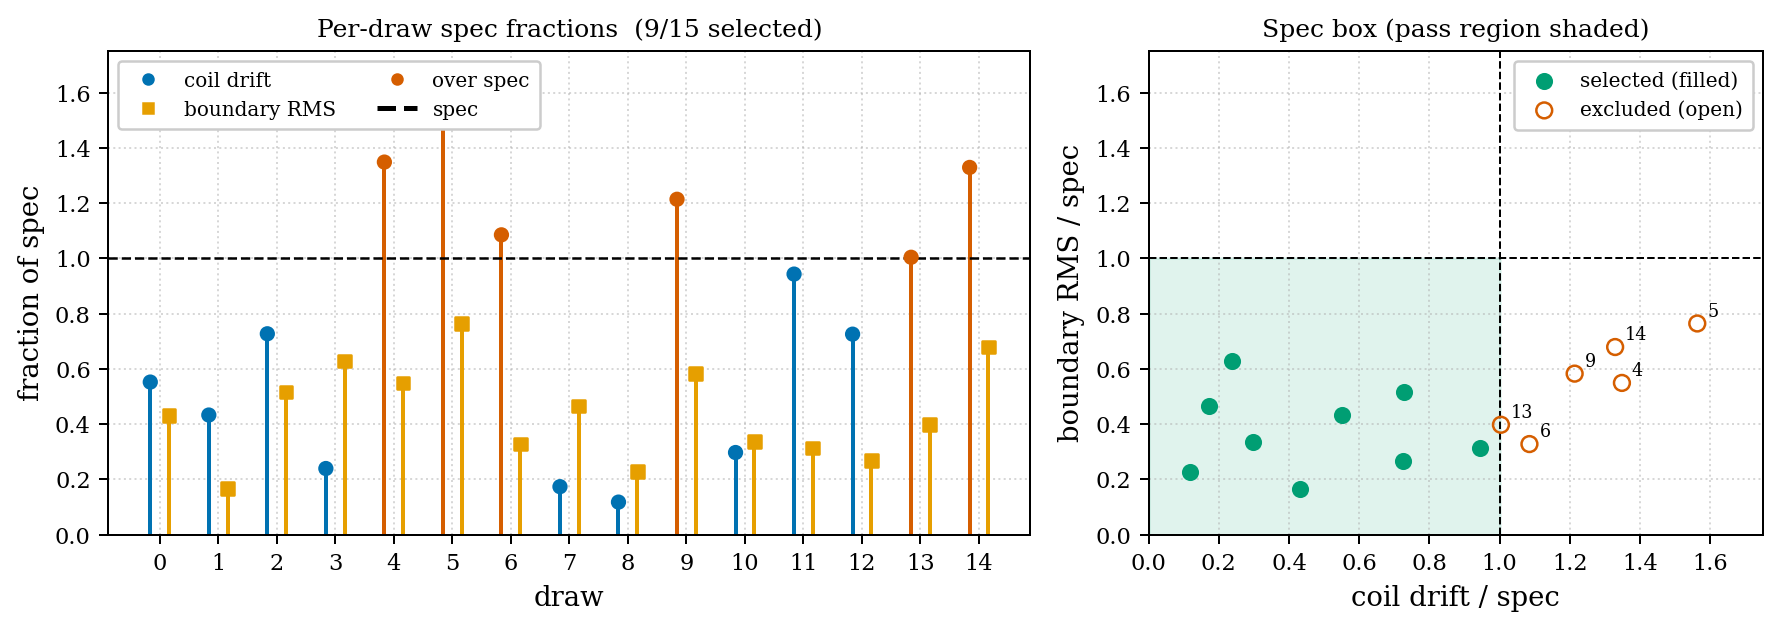

at rms_max_mm=1.5, 12/15 draws would be excluded: [0, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14]


In [13]:
# filter_coil_currents flags: F_max_pct  VSC_max_pct  apply={T|F}  plot={T|F}
cs, _ = bq.filter_coil_currents(HEADER, scan_key=2100, plot=False)
print(f"coil-current in-spec: {cs['n_pass']}/{cs['n_total']} "
      f"({cs['n_fail']} out-of-spec)")
# filter_boundaries flags: rms_max_mm  max_max_mm  apply={T|F}  plot={T|F}
bs, _ = bq.filter_boundaries(HEADER, rms_max_mm=5.0, scan_key=2100, plot=False)
rs = bs['rms_stats']
print(f"boundary RMS [mm]: median {rs['median']:.2f}  95th {rs['p95']:.2f}  max {rs['max']:.2f}")
# select_indices flags: selection={selected|all|excluded}
sel = bq.select_indices(HEADER, scan_key=2100, selection='selected')
exc = bq.select_indices(HEADER, scan_key=2100, selection='excluded')
print(f"selected (deliverable): {len(sel)} draws {sel}")
print(f"excluded (out-of-spec): {len(exc)} draws {exc}")

# plot_spec_summary flags: rms_max_mm
bq.plot_spec_summary(HEADER, scan_key=2100, rms_max_mm=5.0); plt.show()

# What-if: re-screen at a tighter boundary spec WITHOUT writing flags
# (apply=False). The coil spec is hardware (±2%); the boundary cut is an
# analysis choice, so it is the natural knob to tighten.
bs_tight, _ = bq.filter_boundaries(HEADER, rms_max_mm=1.5, scan_key=2100,
                                apply=False, plot=False)
would_fail = sorted(i for i, d in bs_tight['draws'].items() if not d['passes'])
print(f"at rms_max_mm=1.5, {len(would_fail)}/{bs_tight['n_total']} draws "
      f"would be excluded: {would_fail}")


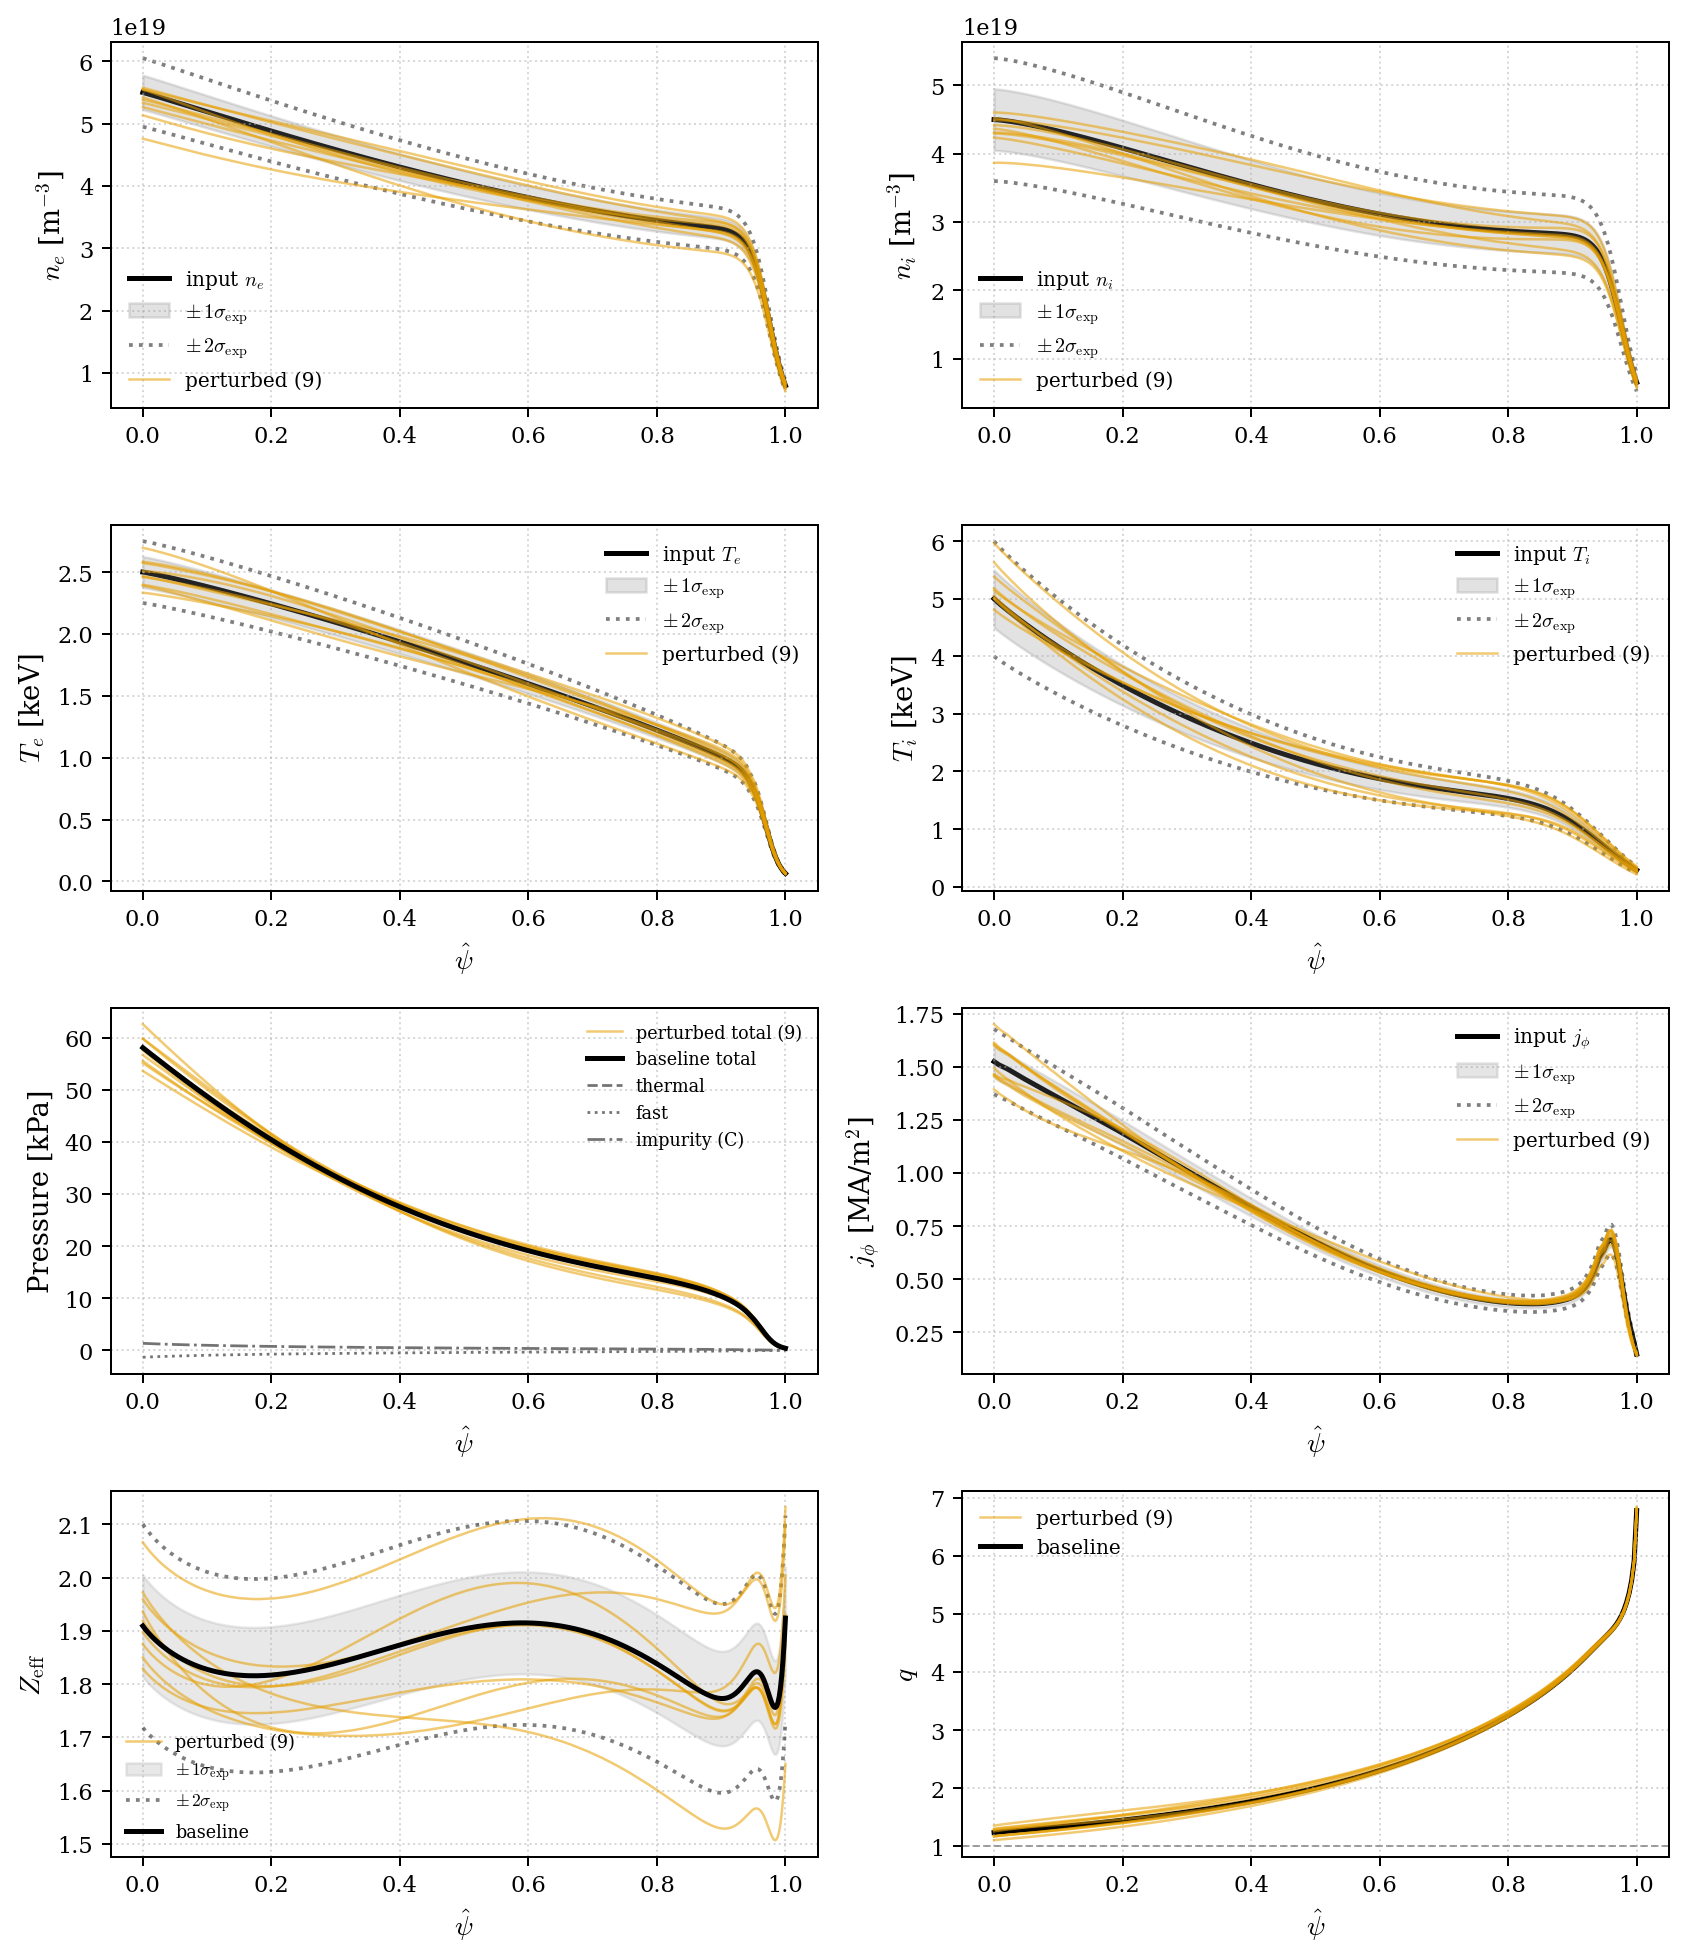

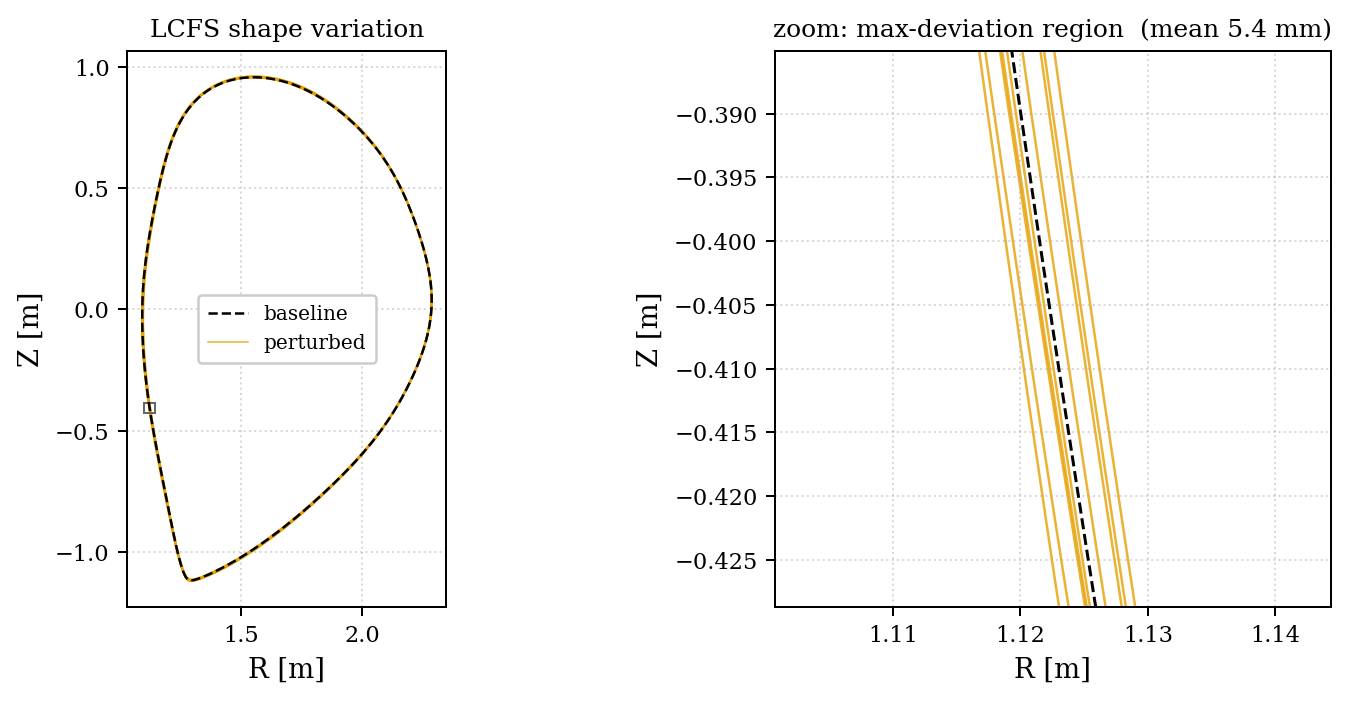

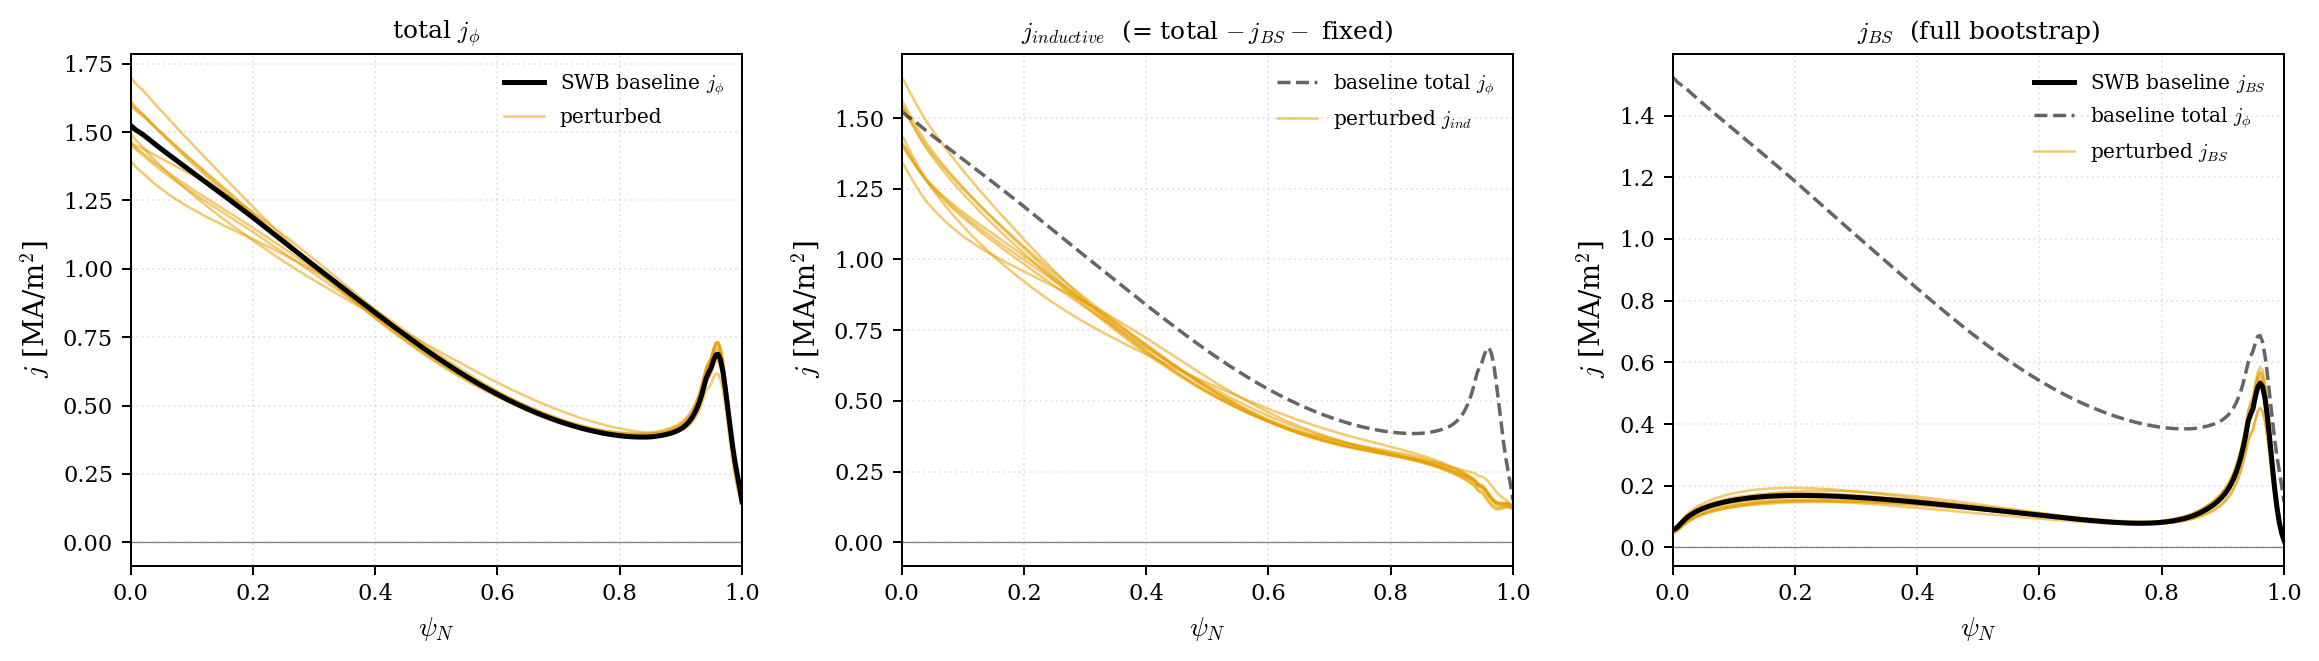

In [14]:
# the bouquet keeping ONLY the in-spec family
bq.plot_bouquet(HEADER + '.h5', scan_key=2100, mode='all', selection='selected');

## 4. ψ-dependent σ profiles (IDA-like)

Flat fractions are a starting point; real diagnostics have **ψ-dependent**
uncertainty — typically worse at the pedestal. `synthetic_ida_sigma(ψ, channel)`
is a deterministic, non-proprietary envelope calibrated to a real DIII-D IDA
analysis. Supplying `uncertainty.sigma_profiles` (absolute σ on the kinetic
grid) overrides the flat scalars per channel for n_e/T_e/T_i. (n_i is derived
from Z_eff, so its envelope follows n_e and Z_eff rather than a standalone σ.)


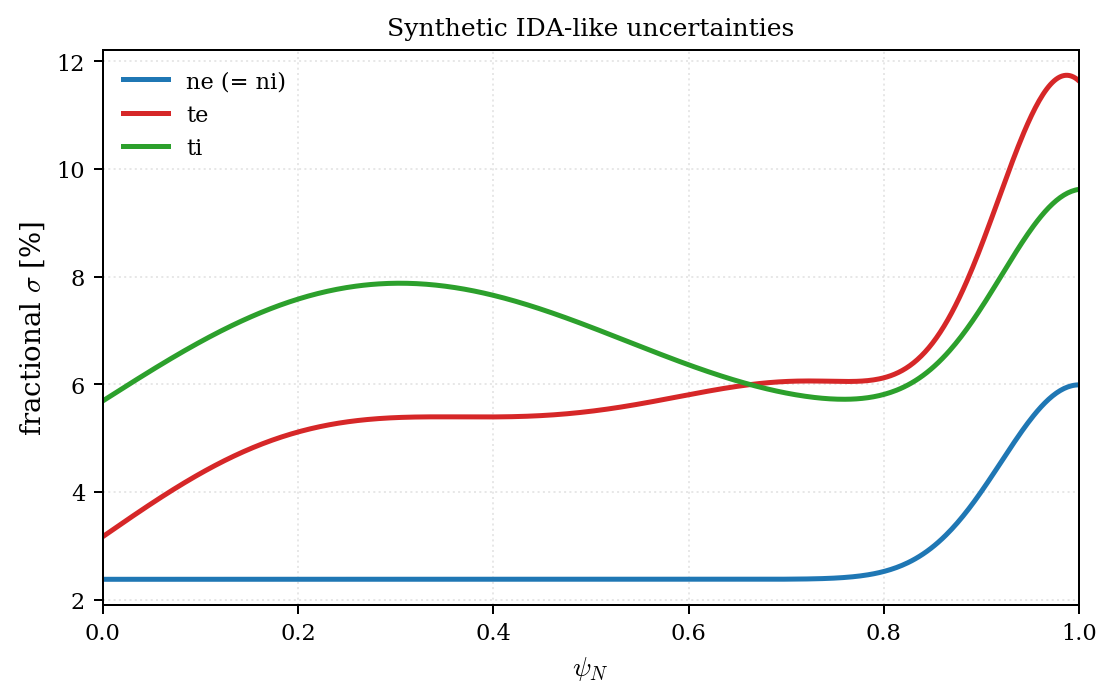

ψ-dependent σ profiles set for ['ne', 'te', 'ni', 'ti']


In [15]:
pk = run.baseline.psi_N_kinetic
# fractional envelopes, for a quick look (ni ≡ ne, so three distinct curves)
fig, ax = plt.subplots(figsize=(7, 4))
for ch, col in [('ne', 'tab:blue'), ('te', 'tab:red'), ('ti', 'tab:green')]:
    ax.plot(pk, bq.synthetic_ida_sigma(pk, ch) * 100, color=col, lw=2,
            label=ch + (' (= ni)' if ch == 'ne' else ''))
ax.set_xlabel(r'$\psi_N$'); ax.set_ylabel(r'fractional $\sigma$ [%]'); ax.set_xlim(0, 1)
ax.grid(alpha=0.3); ax.legend(); ax.set_title('Synthetic IDA-like uncertainties'); plt.show()

# absolute σ profiles -> override the flat scalars
run.uncertainty.sigma_profiles = {
    'ne': bq.synthetic_ida_sigma(pk, 'ne') * run.baseline.ne,
    'te': bq.synthetic_ida_sigma(pk, 'te') * run.baseline.te,
    'ni': bq.synthetic_ida_sigma(pk, 'ni') * run.baseline.ni,
    'ti': bq.synthetic_ida_sigma(pk, 'ti') * run.baseline.ti,
}
print('ψ-dependent σ profiles set for', list(run.uncertainty.sigma_profiles))


## 5. Auxiliary profiles (the switchboard) — and every knob in one place

The Z_eff channel is already on (§2). The **switchboard** is the general
mechanism behind it: supplying a σ on the kinetic grid enables perturbation of
a named auxiliary channel. Beyond `zeff` you can add rotation (`omega_tor`,
`e_r`) and transport (`chi_e`, `chi_i`). The IMAS path auto-fills these
baselines from the dataset; the reconstruction path has only the p-file, so you
**supply baselines manually**.

`zeff` is the *active* channel — each draw samples Z_eff and **derives** n_i via
quasineutrality with `impurity_Z`, one mutually consistent (n_e, n_i, Z_eff,
n_z) set per draw (used by the bootstrap, the archive, and the per-draw p-file
alike). Here we widen its envelope and add the *passive* rotation/transport
channels (perturbed and archived, not GS inputs).

The cell after that is a **look-up table of every knob on the driver**, each
set to the value this notebook runs with — edit any of them and re-run
`generate()` to apply.


In [16]:
x = pk  # kinetic grid
omega = 6.0e4 * (1 - 0.9*x**2)                       # rotation [rad/s]
e_r   = 4.0e3*x - 5.0e4*np.exp(-((x-0.95)/0.04)**2)  # radial field [V/m], edge well
chi_e = 0.5 + 2.5*x**2                               # transport [m^2/s]
chi_i = 0.7*chi_e
zeff  = run.baseline.Zeff               # the real (p-file) Z_eff baseline

# passive channels: supply baseline + σ on the kinetic grid to enable each.
# zeff is already active from §2; here we set an explicit (ψ-dependent) σ that
# overrides the flat zeff_scalar_sigma.
run.uncertainty.aux_baselines = {'omega_tor': omega, 'e_r': e_r,
                                 'chi_e': chi_e, 'chi_i': chi_i}
run.uncertainty.aux_sigmas = {
    'omega_tor': 0.10*np.abs(omega),    # ±10%  (passive)
    'e_r':       0.10*np.abs(e_r) + 1e2,
    'chi_e':     0.20*chi_e,            # ±20%
    'chi_i':     0.20*chi_i,
    'zeff':      0.05*zeff,             # explicit σ (ACTIVE -> bootstrap + derived n_i)
}
print('aux channels enabled:', list(run.uncertainty.aux_sigmas))


aux channels enabled: ['omega_tor', 'e_r', 'chi_e', 'chi_i', 'zeff']


In [17]:
# ── Knob reference: everything tunable on the driver ─────────────────────
# Grouped by config block; every value below is what this notebook runs with.

# — source (reconstruction path) —
run.source.cocos        = 1      # g-file COCOS convention
run.source.impurity_Z   = 6.0    # machine impurity charge (carbon); W~74, Be 4, Ne 10
                                 #   controls Z_eff<->n_i; the IDA path derives n_i from it
run.source.psi_pad      = 1e-3   # LCFS pad for profile/stat queries
run.source.n_k          = 5      # inductive-fit spline knots
run.source.psi_bridge   = 0.99   # Hermite edge-bridge location (j_ind -> 0)
run.source.rescale_j_BS = False  # jointly rescale j_BS in the recon fit
run.source.shelf_psi_N  = 0.0    # flat j_ind core shelf start (0 = off)

# — solver —
# nthreads is intentionally left at its default of 1. Do NOT raise it:
# TokaMaker's OpenMP threads oversubscribe numpy's BLAS and make draws
# SLOWER (~3x), not faster. Use bouquet.parallel for multi-core (one
# BLAS-pinned worker per process).
run.solver.order    = 3          # FE order (2 = faster, 3 & 4 = higher accuracy)
run.solver.F0       = None       # vacuum R*Bt override (None -> from g-file)

# — uncertainty envelope —
# kinetic σ precedence per channel: sigma_profiles (§4) > IDA .cdf > scalars
run.uncertainty.ne_scalar_sigma   = 0.05   # flat fractional σ fallbacks
run.uncertainty.te_scalar_sigma   = 0.05
run.uncertainty.ni_scalar_sigma   = 0.10   # ions: harder to diagnose
                                           #   (unused while the zeff channel
                                           #    is active: n_i is derived)
run.uncertainty.ti_scalar_sigma   = 0.10
run.uncertainty.jphi_scalar_sigma = 0.05   # fractional σ on |j_phi|
run.uncertainty.zeff_scalar_sigma = 0.05   # ENABLES the Z_eff channel (0.0 = off,
                                           #   then n_i drawn independently)
run.uncertainty.n_ls = 0.5                 # GPR correlation lengths [ψ_N]:
run.uncertainty.t_ls = 0.4                 #   smaller = wigglier draws
run.uncertainty.j_ls = 0.25
run.uncertainty.ida_path = None            # IDA .cdf -> *_err datasets as σ
# aux_sigmas / aux_baselines: the auxiliary channels (cell above);
# aux_length_scales: per-channel GPR length, default 0.4 when unset

# — generation —
run.generation.n_equils           = 15      # draws per run
run.generation.seed               = 42     # GPR reproducibility (solver: see nthreads)
run.generation.l_i_tolerance      = 0.05   # l_i acceptance band (FRACTION of target)
run.generation.constrain_sawteeth = False  # reject draws with q0 < 1
run.generation.recalculate_j_BS   = True   # per-draw Redl bootstrap (else keep baseline j_BS)
run.generation.jBS_scale_range    = (0.99, 1.01)  # multiplicative j_BS spread per draw
run.generation.swb_iterations     = 3      # bootstrap self-consistency iterations (2 = faster)
run.generation.coil_drift         = 0.01   # final hard per-coil drift bound (fraction)
run.generation.homotopy_passes    = [(0.05, 0.10), (0.02, 0.05), (0.01, 0.01)]
                                           # (F, VSC) bound schedule, loose -> tight
run.generation.diagnostic_plots   = False  # per-draw solver figures (debug)

# — filtering (the in-spec screen of §3) —
run.filtering.inspec_F_max   = 0.02   # non-VSC F-coil spec (±2%, DIII-D hardware)
run.filtering.inspec_VSC_max = 0.02   # VSC-pair spec
run.filtering.rms_max_mm     = 5.0    # LCFS RMS cut [mm] (analysis choice)

# — output —
run.config.verbose = False   # stream solver chatter (else captured to *_log)
print('knob reference applied — values match the run above unless edited')


knob reference applied — values match the run above unless edited


## 6. Comprehensive re-run + outputs

Now generate again with the ψ-dependent σ **and** the switchboard active. The
solver and reconstructed baseline are reused (no re-reconstruction); we just
write to a new file and re-screen. Then the same four plots, plus the perturbed
extra profiles.

In [18]:
HEADER_FULL = 'D3Dlike_Hmode_full'
run.config.output_header = HEADER_FULL
run.generate(); run.filter(); run.export()

  [sigma-source] sigma_ne   <- explicit sigma_profiles      (peak 1.55e+18)
  [sigma-source] sigma_te   <- explicit sigma_profiles      (peak 115.3)
  [sigma-source] sigma_ni   <- explicit sigma_profiles      (peak 1.301e+18)
  [sigma-source] sigma_ti   <- explicit sigma_profiles      (peak 284.9)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 7.659e+04)



=== Bouquet — D3Dlike_Hmode_full ================  9/15 in-spec (60%)
  draws         15 generated
  coil spec     9/15 within ±2%   (6 out-of-spec)
  boundary      RMS median 2.49 mm   max 4.45 mm


'D3Dlike_Hmode_full_selected.h5'

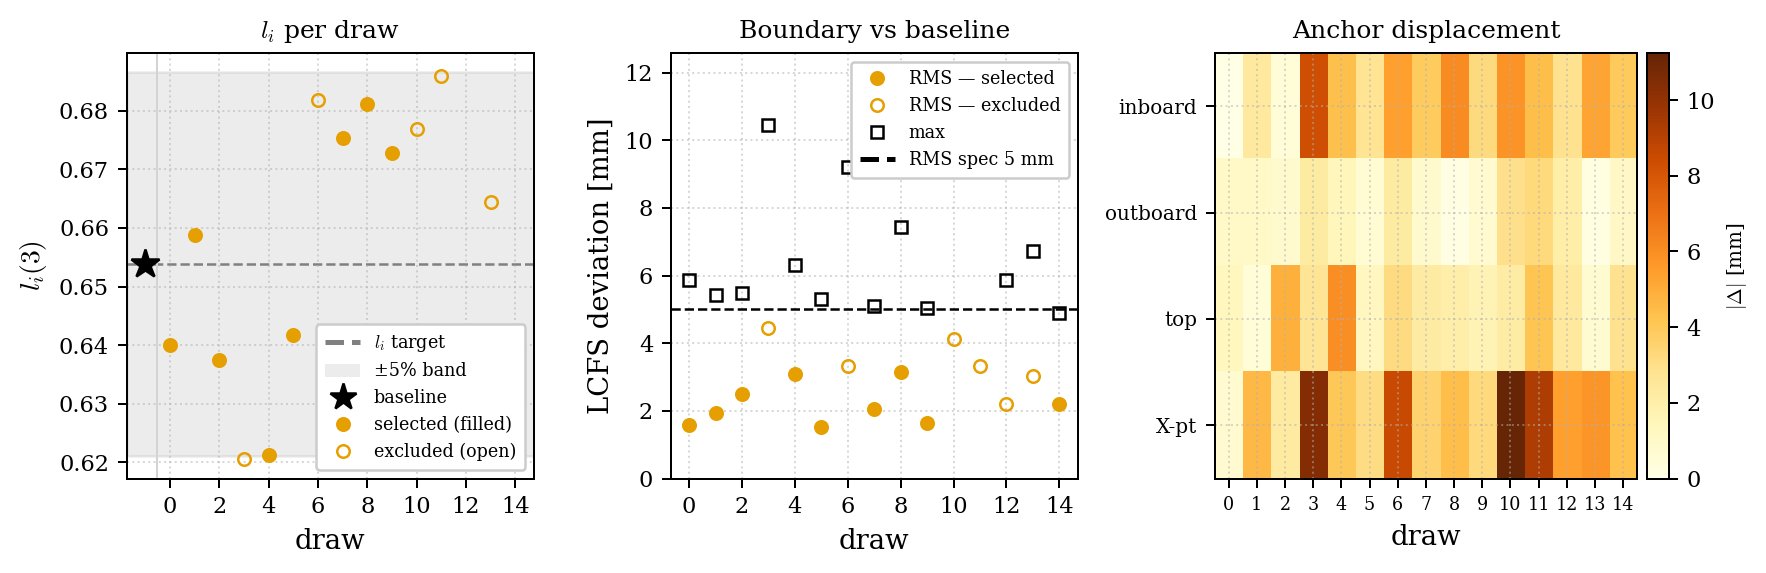

In [19]:
bq.plot_traces(HEADER_FULL + '.h5', scan_key=2100, li_band=run.generation.l_i_tolerance,
            rms_max_mm=run.filtering.rms_max_mm); plt.show()


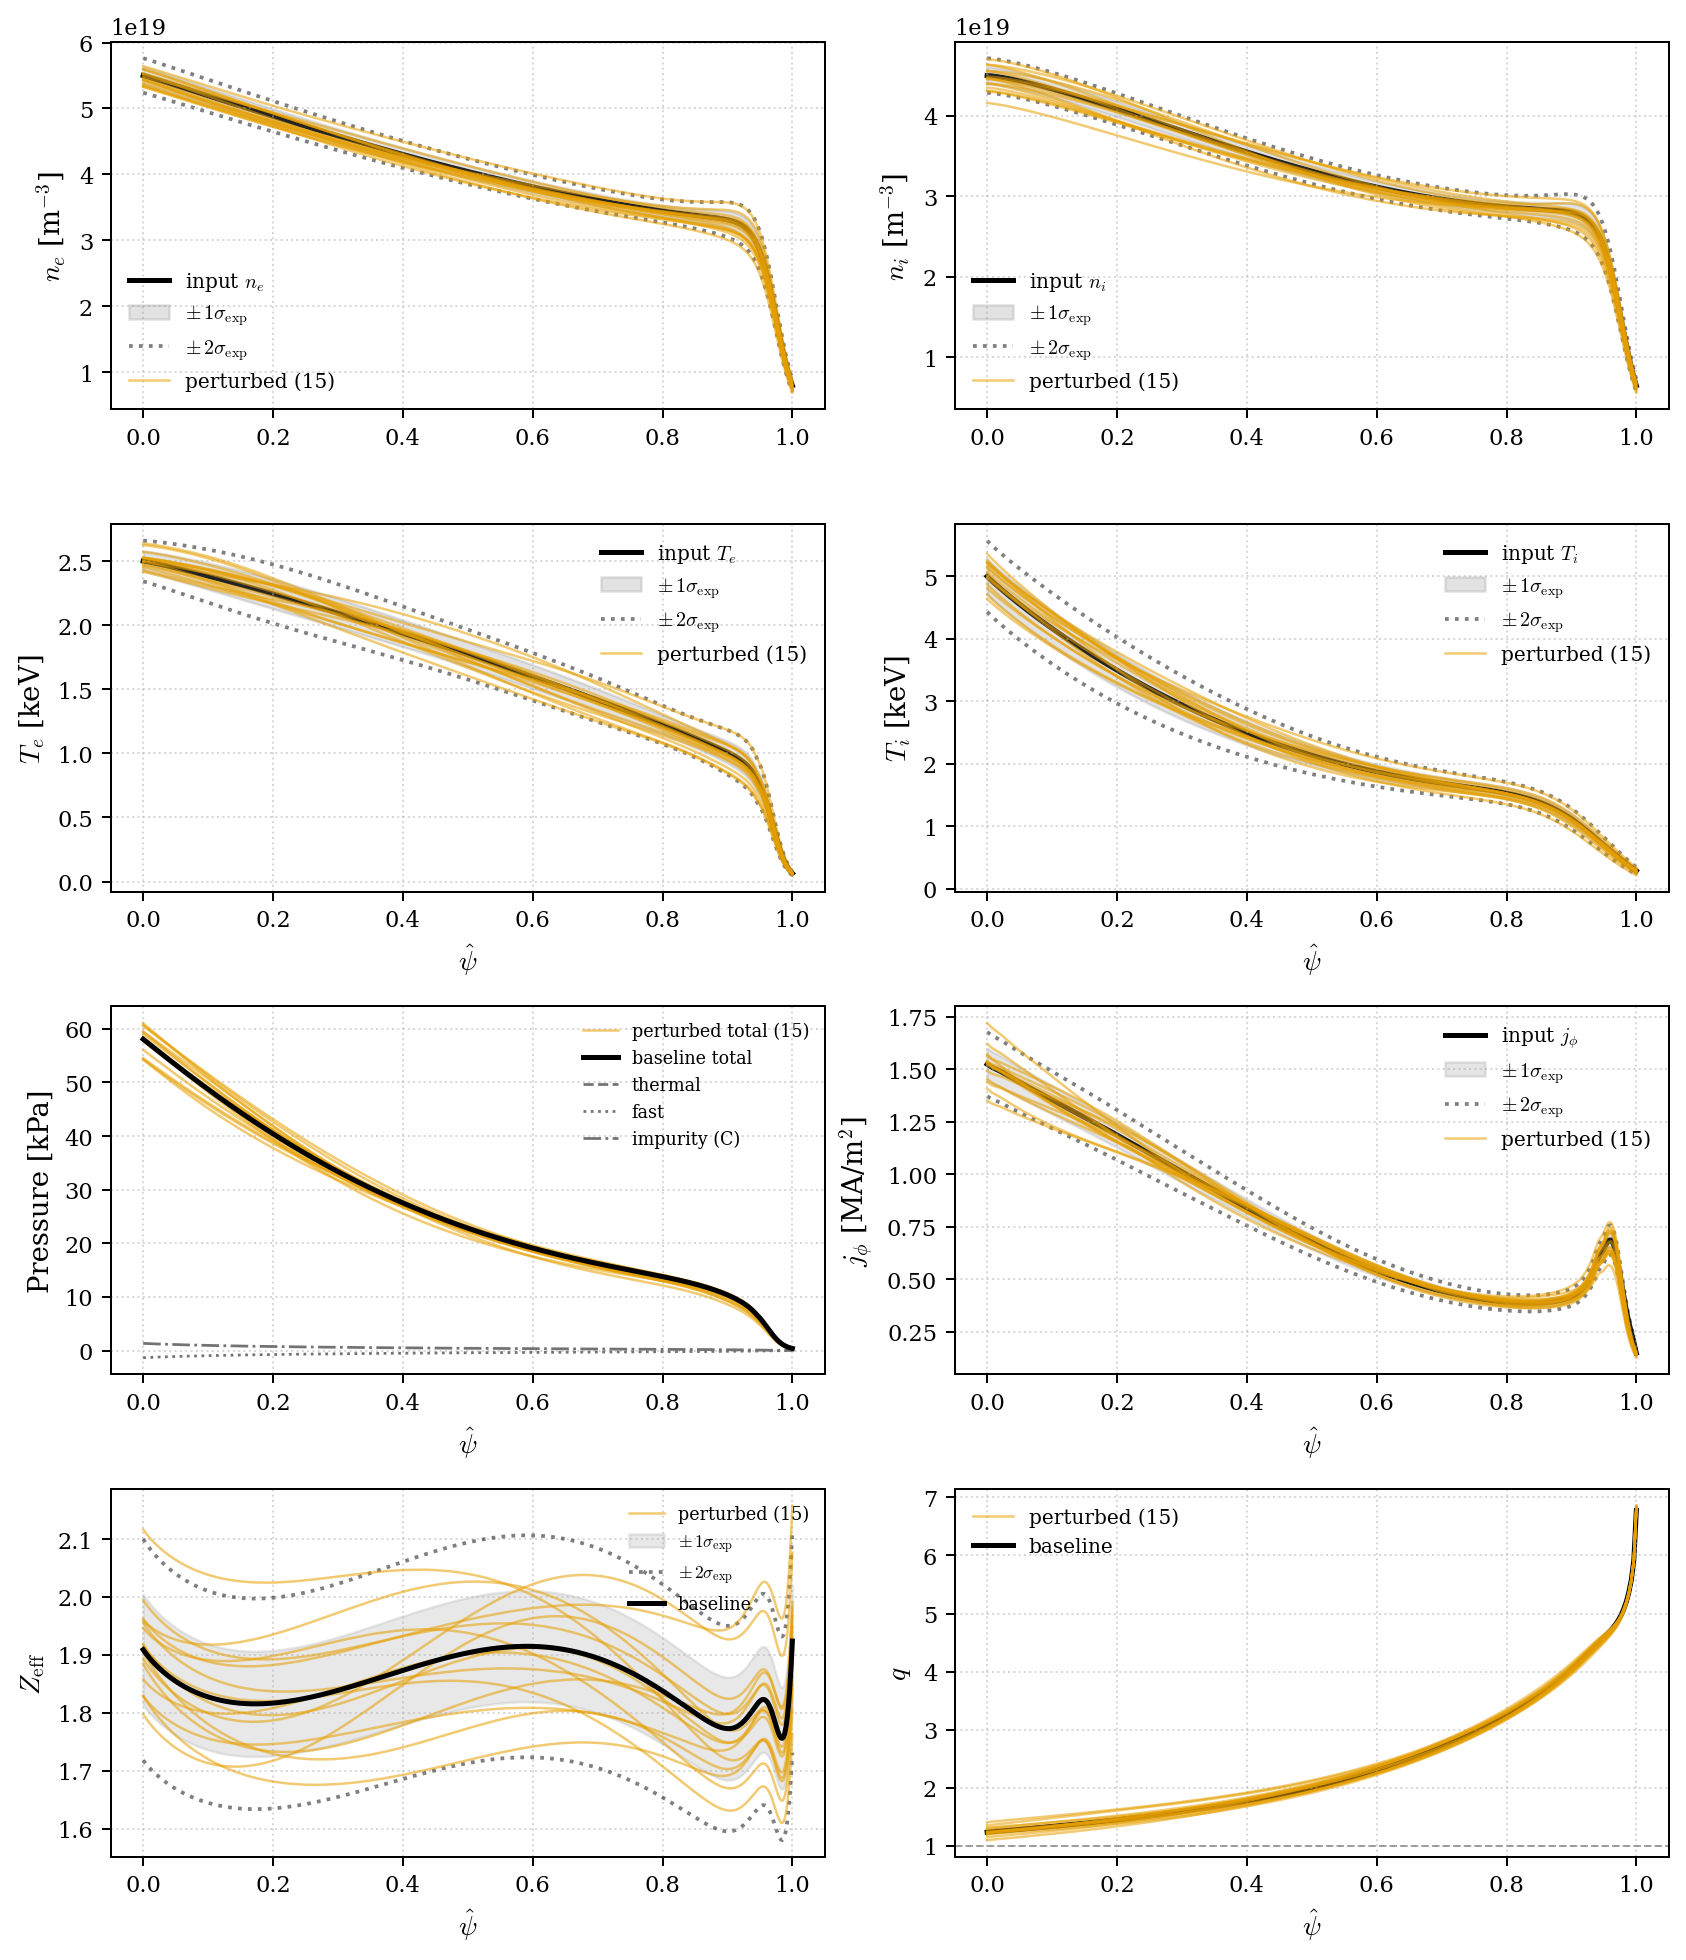

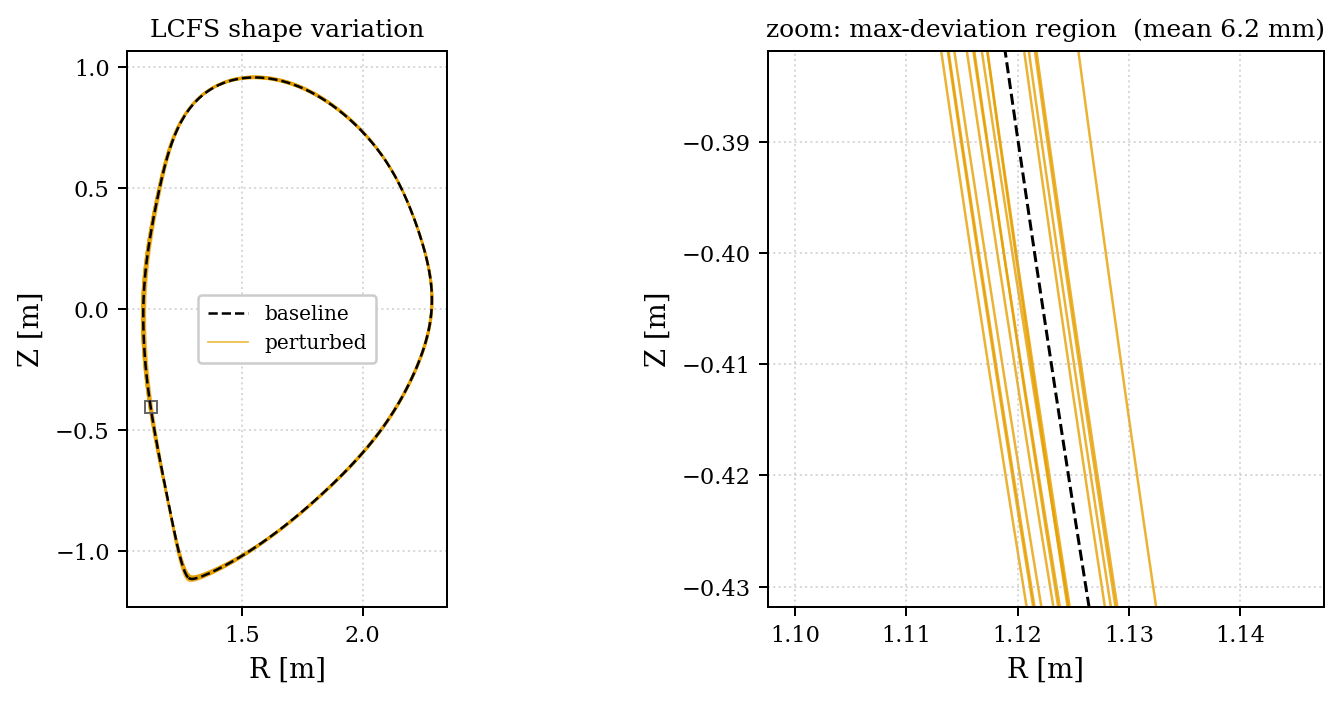

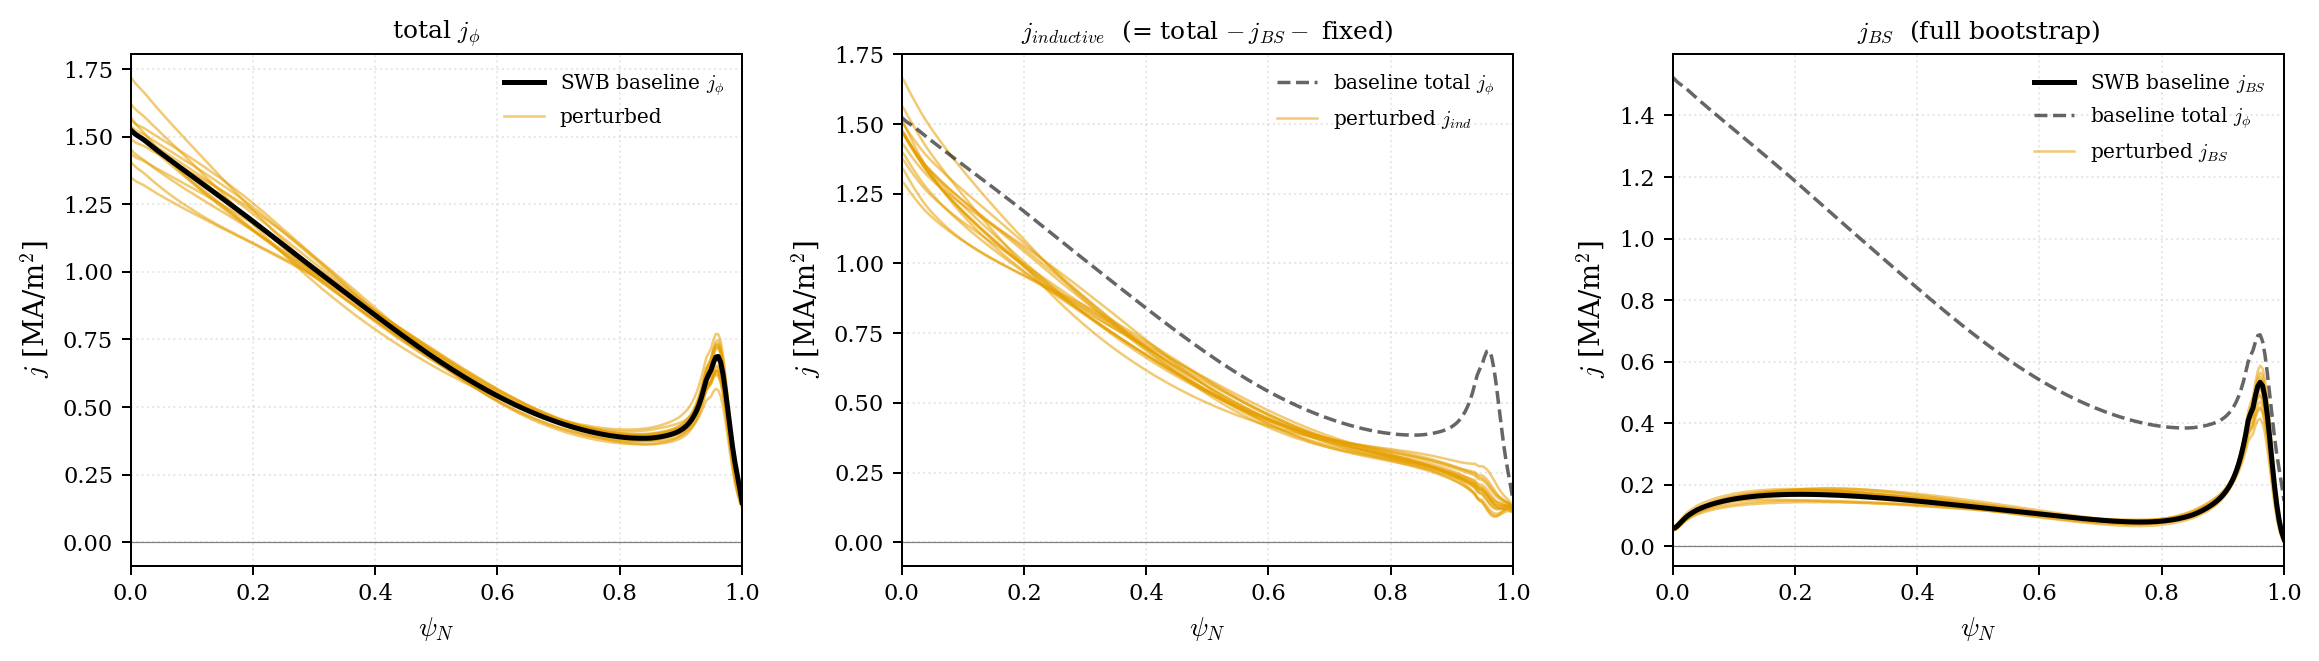

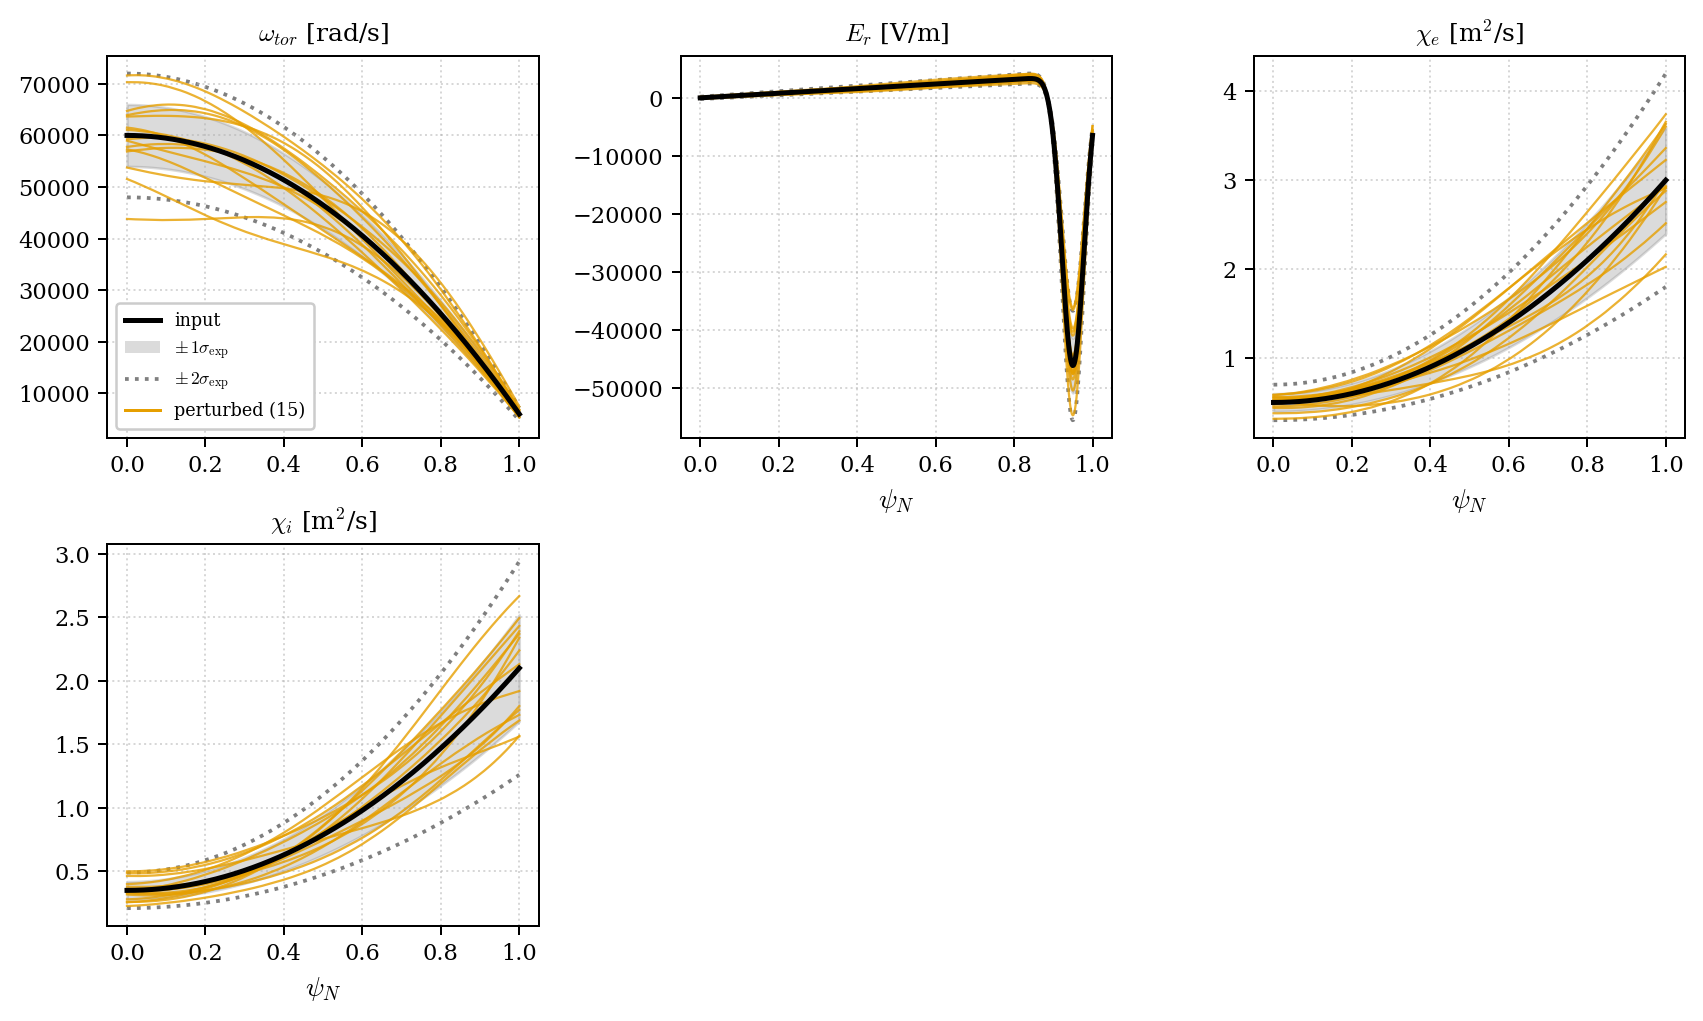

In [20]:
bq.plot_bouquet(HEADER_FULL + '.h5', scan_key=2100, mode='all');

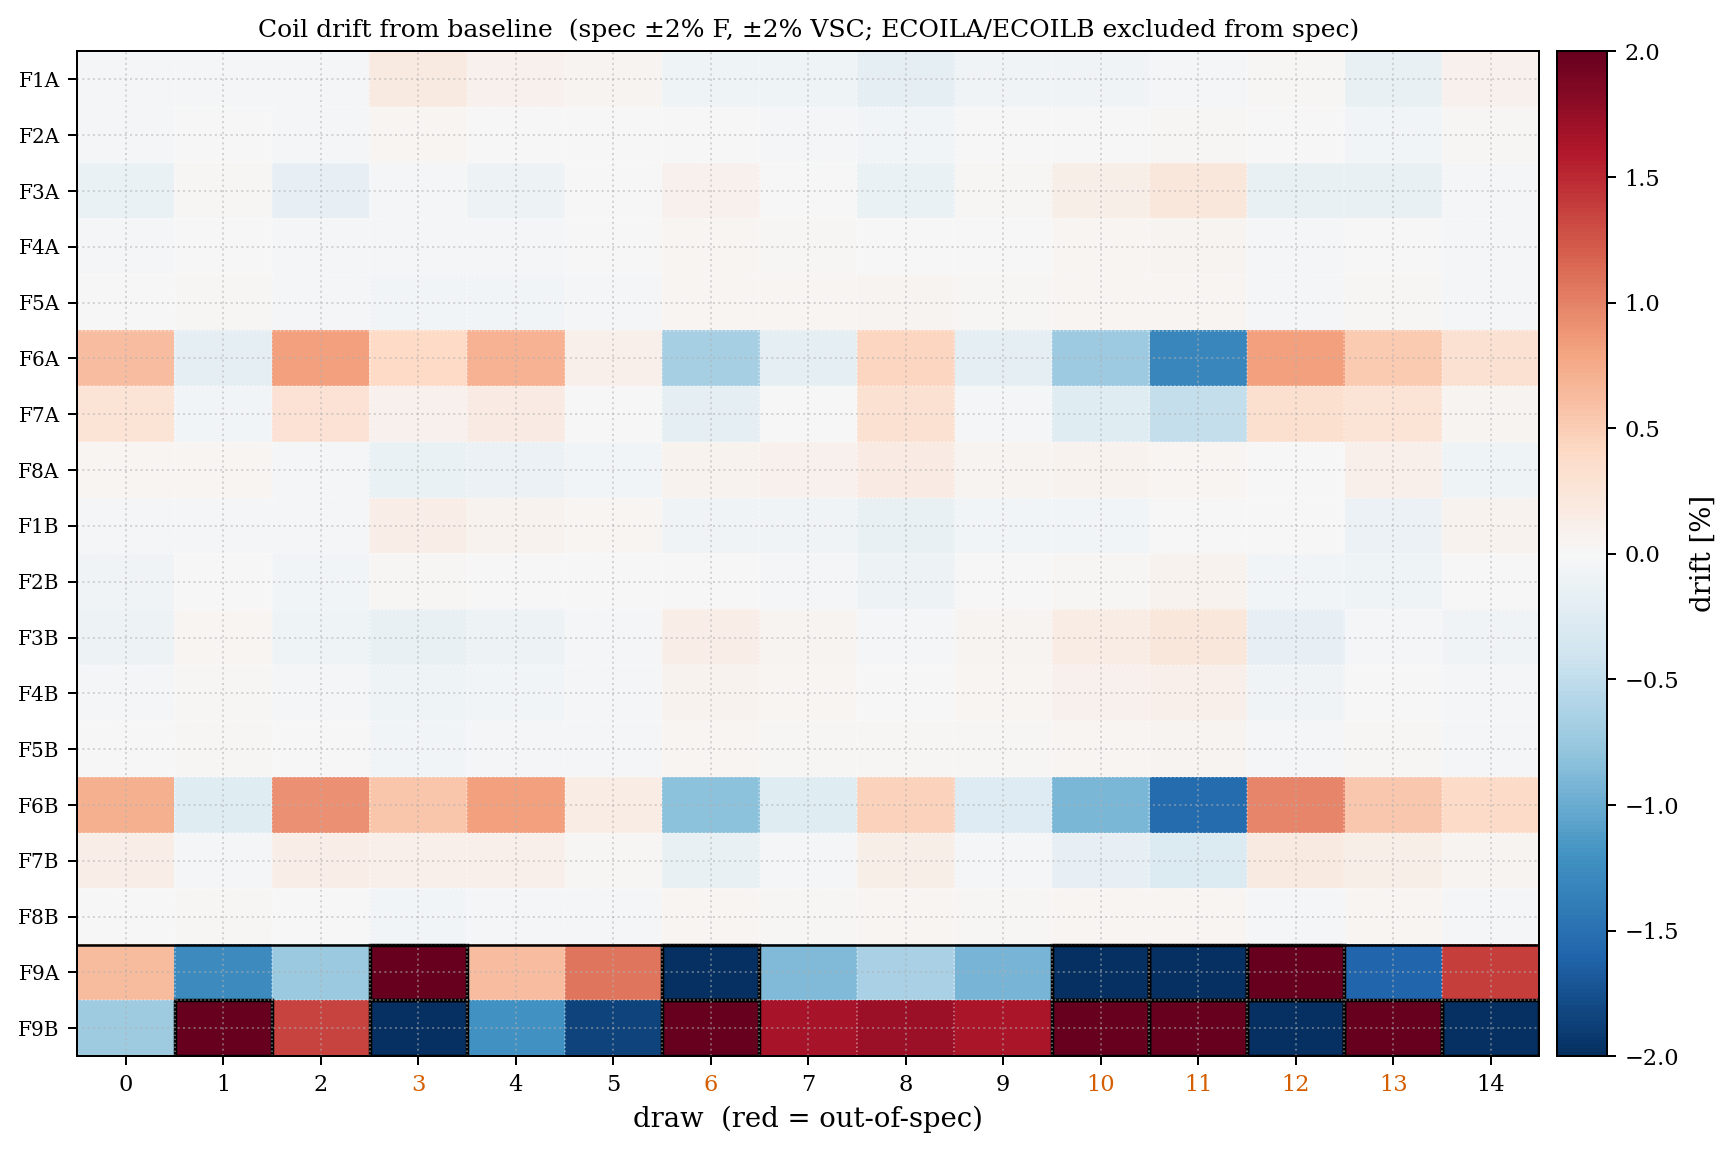

In [21]:
bq.plot_coil_currents(HEADER_FULL + '.h5', scan_key=2100); plt.show()


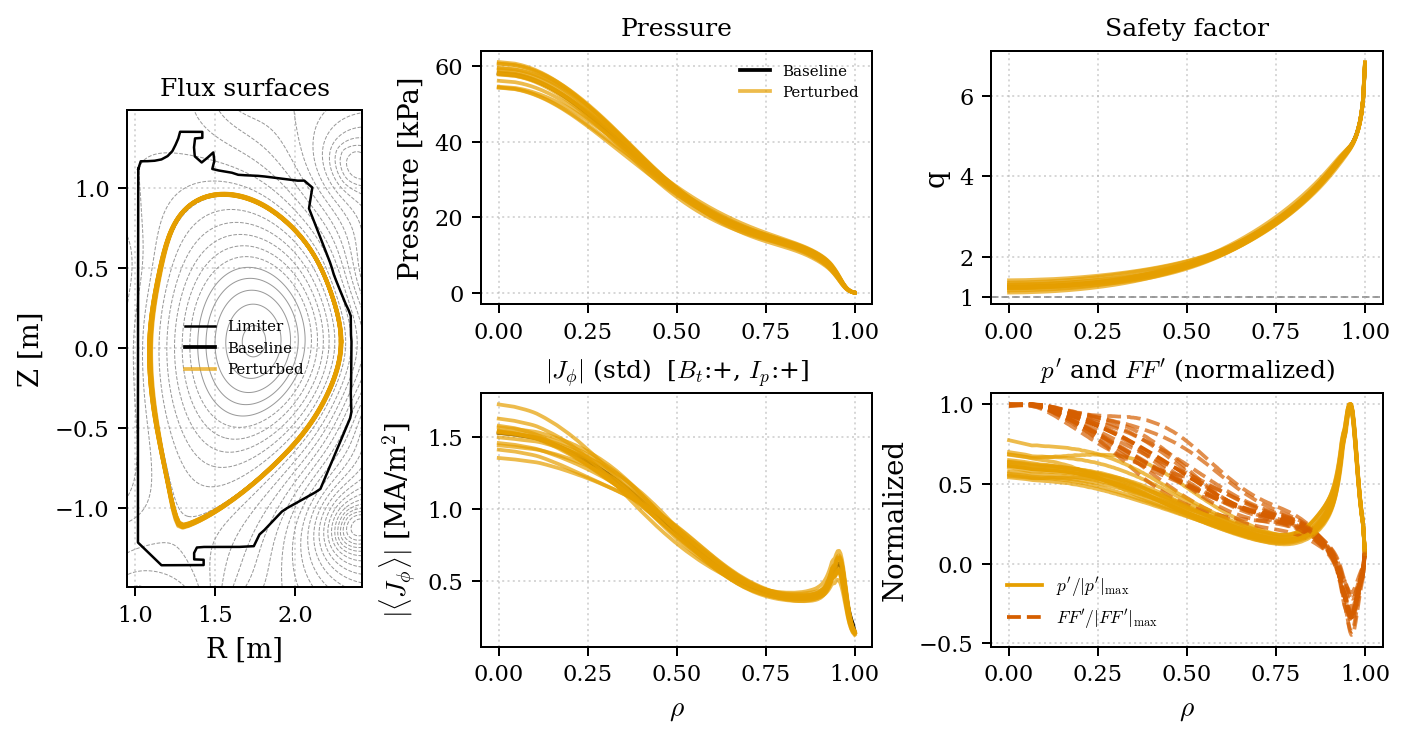

In [22]:
bq.plot_geqdsk_bouquet(h5path=HEADER_FULL + '.h5', scan_key=2100, x_coord='rho'); plt.show()

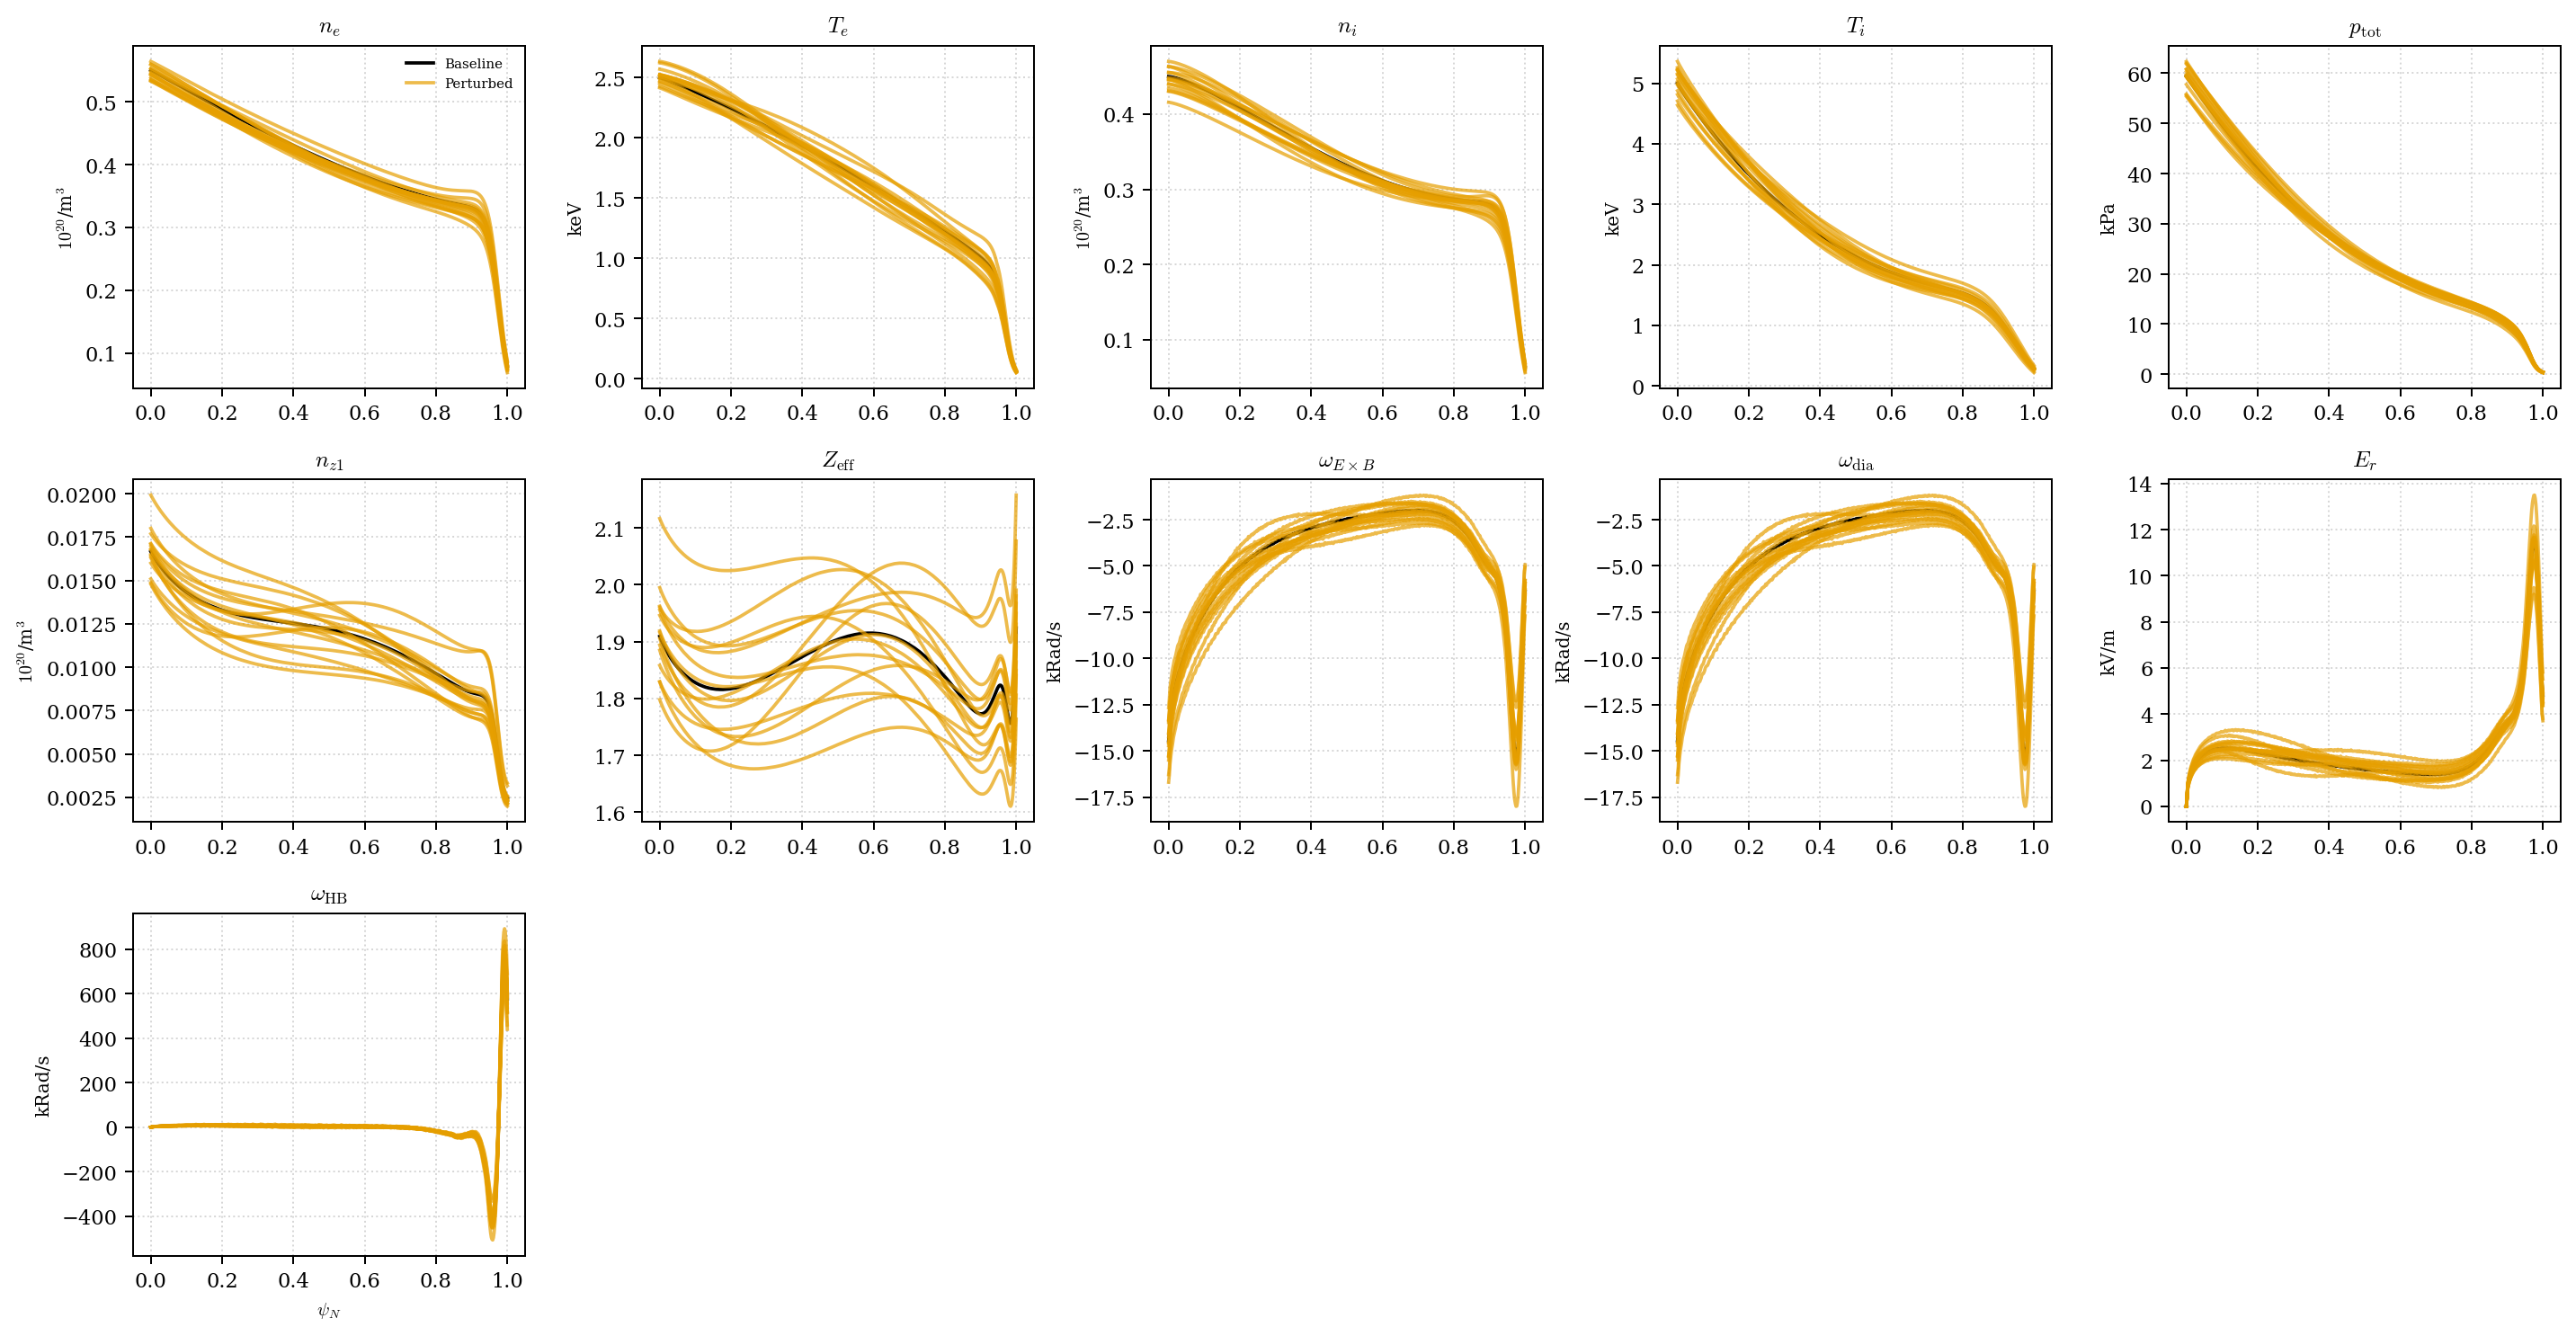

In [23]:
bq.plot_pfile_bouquet(h5path=HEADER_FULL + '.h5', scan_key=2100, x_coord='psi_N'); plt.show()

The perturbed **auxiliary** profiles stored with each draw (active Z_eff +
passive ω/E_r/χ), with the input baseline and its ±1σ/±2σ envelopes:


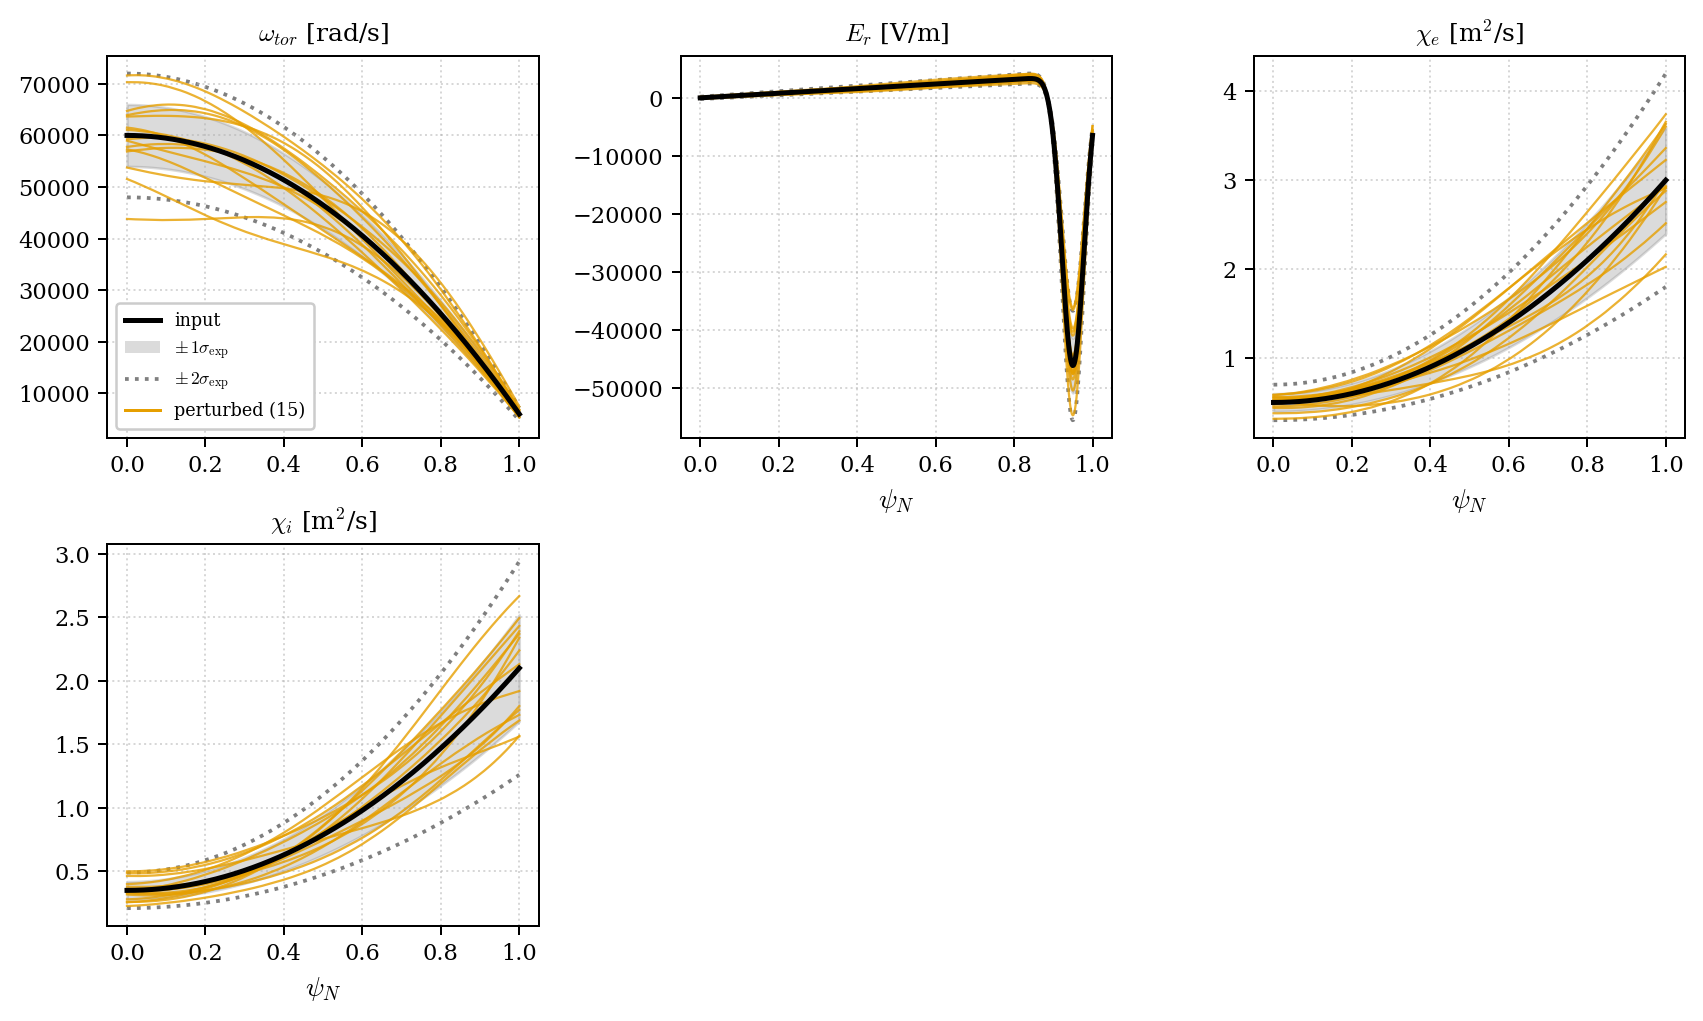

In [24]:
# plot_aux_profiles flags: names=<aux subset>  selection={all|selected|excluded}
bq.plot_aux_profiles(HEADER_FULL + '.h5', scan_key=2100); plt.show()


## 8. Working with the output `.h5`

Every run writes a **self-contained** HDF5 archive — per-draw kinetic profiles,
separated currents, scalar diagnostics, coil currents, and the raw EFIT g-file
+ Osborne p-file bytes for each perturbed equilibrium. Nothing external is
needed to reconstruct a draw.


In [25]:
# list_equilibrium_indices flags: scan_key   |   load_equilibrium flags: count=<draw idx>  scan_key  eqdsk_out_dir
H5 = HEADER_FULL + '.h5'
print('all draws     :', bq.list_equilibrium_indices(H5, scan_key=2100))
print('selected (OK) :', bq.select_indices(HEADER_FULL, scan_key=2100, selection='selected'))

# one draw: profiles + scalars + raw g-file/p-file bytes, all bundled
d = bq.load_equilibrium(HEADER_FULL, count=0, scan_key=2100)
print('\nprofile arrays:', [k for k, v in d.items() if hasattr(v, 'shape')][:6], '...')
print(f"scalars: l_i(1)={d['l_i(1)']:.3f}  l_i(3)={d['l_i(3)']:.3f}")
print('raw bytes present:', 'eqdsk_bytes' in d, '(g-file) /', 'pfile_bytes' in d, '(p-file)')

# the archive is plain HDF5 -- you can also crack it open with h5py directly.
# Groups are scan/<scan_key>/<draw_index>; per-draw scalars live in .attrs:
import h5py
with h5py.File(H5, 'r') as hf:
    a = hf['scan/2100/0'].attrs   # scan_key=2100, draw 0
    print(f"in_spec={bool(a['selected'])}  "
          f"max_F_drift={a['max_F_drift_pct']:.2f}%  max_VSC_drift={a['max_VSC_drift_pct']:.2f}%")


all draws     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
selected (OK) : [0, 1, 2, 4, 5, 7, 8, 9, 14]

profile arrays: ['psi_N', 'j_phi', 'j_BS', 'j_inductive', 'n_e', 'T_e'] ...
scalars: l_i(1)=0.852  l_i(3)=0.640
raw bytes present: True (g-file) / True (p-file)
in_spec=True  max_F_drift=0.72%  max_VSC_drift=0.74%


In [26]:
# parse a draw's raw g-file into a full GEQDSKEquilibrium (no file on disk)
eq = bq.read_eqdsk_from_bytes(d['eqdsk_bytes'], bq.read_geqdsk)
print(f"draw 0 equilibrium: Ip={abs(eq.Ip)/1e6:.3f} MA, l_i(1)={eq.li['li(1)']:.3f}, "
      f"kappa={eq.geometry['kappa'][-1]:.3f}, q95={float(__import__('numpy').interp(0.95, eq.psi_N, eq.qpsi)):.2f}")

# ...or dump this draw's g-file + p-file to disk for an external code
import os
res = bq.load_equilibrium(HEADER_FULL, count=0, scan_key=2100, eqdsk_out_dir='extracted')
with open(os.path.join('extracted', 'draw0.peqdsk'), 'wb') as fh:
    fh.write(d['pfile_bytes'])
print('wrote', res['eqdsk_filepath'], '+ extracted/draw0.peqdsk')


draw 0 equilibrium: Ip=1.200 MA, l_i(1)=0.825, kappa=1.740, q95=4.57
wrote /Users/danielburgess/Desktop/plasma/bouquet/examples/D3D-like/extracted/D3Dlike_Hmode_full_2100_0.eqdsk + extracted/draw0.peqdsk
